# Mobil Para Transferlerinde Dolandırıcılık Tespiti
## PaySim Veri Seti ile Random Forest, LightGBM ve Isolation Forest Karşılaştırması

### Projenin Amacı

Bu projenin amacı, mobil para transferlerinde gerçekleşen işlemler arasından **dolandırıcılık (fraud) işlemlerini tespit edebilen bir makine öğrenmesi modeli geliştirmektir**. Çalışmada Kaggle üzerinde yayımlanan **PaySim** veri seti kullanılmıştır. PaySim, gerçek mobil para transferi davranışlarından yararlanılarak oluşturulmuş **sentetik bir finansal işlem veri setidir**.

Dolandırıcılık tespiti problemi, klasik bir **ikili sınıflandırma (binary classification)** problemidir:

- **0 → Normal işlem**
- **1 → Dolandırıcılık işlemi**

Bu veri setindeki en önemli zorluk, fraud işlemlerinin toplam işlemler içinde çok az olmasıdır. Veri setinde fraud oranı yaklaşık **%0,1291**'dir. Bu nedenle yalnızca `accuracy` metriğine bakmak yanıltıcı olabilir. Projede özellikle **Precision, Recall, F1-Score, PR-AUC ve ROC-AUC** metrikleri kullanılmıştır.

---

### Veri Setinin Boyutu

PaySim veri seti başlangıçta:

- **6.362.620 satır**
- **11 sütun**

içermektedir.

Fraud işlemlerinin yalnızca `TRANSFER` ve `CASH_OUT` işlem türlerinde görüldüğü EDA aşamasında tespit edilmiştir. Bu nedenle modelleme aşamasında yalnızca bu iki işlem türü kullanılmış ve veri seti **2.770.409 satıra** düşürülmüştür.

> Bu filtreleme nedeniyle geliştirilen model, PaySim içindeki tüm işlem türlerini değil, fraud görülen `TRANSFER` ve `CASH_OUT` işlemlerini kapsamaktadır.

---

### Veri Setindeki Değişkenler

| Değişken | Açıklama |
|---|---|
| `step` | İşlemin gerçekleştiği zaman adımıdır. PaySim'de 1 step yaklaşık 1 saati temsil eder. |
| `type` | İşlem türüdür: PAYMENT, TRANSFER, CASH_OUT, CASH_IN veya DEBIT. |
| `amount` | İşlem tutarıdır. |
| `nameOrig` | İşlemi başlatan hesabın anonim kimliğidir. |
| `oldbalanceOrg` | Gönderici hesabın işlemden önceki bakiyesidir. |
| `newbalanceOrig` | Gönderici hesabın işlemden sonraki bakiyesidir. |
| `nameDest` | Alıcı hesabın anonim kimliğidir. |
| `oldbalanceDest` | Alıcı hesabın işlemden önceki bakiyesidir. |
| `newbalanceDest` | Alıcı hesabın işlemden sonraki bakiyesidir. |
| `isFraud` | Hedef değişkendir. 1 fraud, 0 normal işlem anlamına gelir. |
| `isFlaggedFraud` | PaySim tarafından belirli yüksek tutarlı transferler için üretilmiş kural tabanlı fraud bayrağıdır. |

`nameOrig` ve `nameDest` yüksek kardinaliteli anonim kimlik değişkenleri oldukları için modele doğrudan dahil edilmemiştir. `isFlaggedFraud` ise sistem tarafından oluşturulmuş fraud ile ilişkili bir bayrak olduğundan, hedefe çok yakın bir sinyal oluşturabileceği için tahmin değişkeni olarak kullanılmamıştır.

---

### Araştırma Hipotezleri

| # | Hipotez |
|---|---|
| **H1** | Dolandırıcılık işlemleri belirli işlem türlerinde yoğunlaşmaktadır. |
| **H2** | Bakiye tutarsızlığı değişkenleri fraud sinyalini güçlendirmektedir. |
| **H3** | Gözetimli modeller, gözetimsiz anomali tespit modelinden daha yüksek performans gösterecektir. |
| **H4** | Karar eşiğinin validation seti üzerinde optimize edilmesi sınıflandırma davranışını değiştirecektir. |
| **H5** | İşlem sonrası bakiye bilgilerinin modele dahil edilmesi performansı yapay biçimde yükseltecektir. |
| **H6** | Fraud oranı zaman içerisinde değişmektedir ve zamansal train-validation-test ayrımı bu dağılım değişimini ortaya çıkaracaktır. |

---

### Proje Akışı

1. Veri setinin yüklenmesi ve genel yapısının incelenmesi  
2. Eksik değer ve sınıf dağılımı analizi  
3. İşlem türlerine göre fraud dağılımının incelenmesi  
4. İşlem tutarlarının analiz edilmesi  
5. Feature Engineering ile yeni değişkenlerin oluşturulması  
6. Veri sızıntısı oluşturabilecek değişkenlerin ayrılması  
7. Zamansal Train–Validation–Test ayrımı  
8. Random Forest, LightGBM ve Isolation Forest modellerinin karşılaştırılması  
9. LightGBM için Optuna ile hiperparametre optimizasyonu  
10. Validation setinde karar eşiği optimizasyonu  
11. Test setinde final değerlendirme  
12. İşlem sonrası değişkenlerle veri sızıntısı deneyi  
13. SHAP ile model açıklanabilirliği  
14. Hipotezlerin ve proje sonuçlarının değerlendirilmesi


## 1. Kütüphanelerin İçe Aktarılması

Bu bölümde veri analizi, görselleştirme, modelleme, hiperparametre optimizasyonu ve model açıklanabilirliği için gerekli Python kütüphaneleri içe aktarılmıştır.

- **NumPy ve Pandas:** Veri işleme ve sayısal hesaplamalar
- **Matplotlib ve Seaborn:** Grafik ve görselleştirmeler
- **Scikit-learn:** Random Forest, Isolation Forest ve değerlendirme metrikleri
- **LightGBM:** Büyük veri setlerinde hızlı ve güçlü gradient boosting modeli
- **Optuna:** LightGBM hiperparametrelerinin otomatik olarak optimize edilmesi
- **SHAP:** Modelin hangi değişkenlerden ne ölçüde etkilendiğinin açıklanması

Çalışmanın tekrar üretilebilir olması için `RANDOM_STATE = 42` sabit tutulmuştur.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score, roc_auc_score,
    f1_score, precision_score, recall_score, PrecisionRecallDisplay
)

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Kutuphaneler yuklendi.")

Kutuphaneler yuklendi.


`RANDOM_STATE = 42` değeri notebook boyunca sabit tutulmuştur. Böylece rastgelelik içeren modelleme işlemlerinin mümkün olduğunca aynı sonuçları üretmesi ve çalışmanın tekrar edilebilir olması amaçlanmıştır.

## 2. Veri Setinin Yüklenmesi

Bu aşamada PaySim veri seti CSV formatında okunmuştur. Kod, olası farklı dosya adlarını kontrol ederek mevcut dosyayı bulmakta ve Pandas DataFrame yapısına aktarmaktadır.

Veri setinin yüklenmesinden sonra satır ve sütun sayısı kontrol edilmiştir. Başlangıç veri seti **6.362.620 satır ve 11 sütundan** oluşmaktadır. Bu büyüklük, çalışmanın yüksek hacimli bir finansal işlem verisi üzerinde gerçekleştirildiğini göstermektedir.

In [2]:
CANDIDATE_PATHS = ["PS_20174392719_1491204439457_log.csv", "paysim.csv", "PaySim.csv"]

def load_real_paysim(paths):
    import os
    for p in paths:
        if os.path.exists(p):
            print(f"Gercek PaySim verisi bulundu: {p}")
            return pd.read_csv(p)
    return None

df = load_real_paysim(CANDIDATE_PATHS)
if df is None:
    raise FileNotFoundError("paysim.csv bulunamadi. Dosyayi notebook ile ayni klasore koyun.")

print(f"\nVeri seti boyutu: {df.shape[0]:,} satir x {df.shape[1]} sutun")
df.head()

Gercek PaySim verisi bulundu: paysim.csv

Veri seti boyutu: 6,362,620 satir x 11 sutun


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


Dosyanın bulunamaması durumunda kullanıcıya açık bir hata mesajı verilmektedir. Çalışmanın sorunsuz yürütülebilmesi için PaySim CSV dosyasının notebook ile aynı klasörde bulunması yeterlidir.

## 3. Keşifsel Veri Analizi (EDA)

Keşifsel Veri Analizi'nin amacı, modelleme öncesinde veri setinin yapısını anlamak, hedef değişkenin dağılımını incelemek, olası veri kalitesi problemlerini belirlemek ve fraud ile ilişkili temel örüntüleri ortaya çıkarmaktır.

Bu aşamada özellikle şu sorulara cevap aranmıştır:

- Veri setinde eksik değer var mı?
- Fraud işlemleri ne kadar nadir?
- Fraud belirli işlem türlerinde mi yoğunlaşıyor?
- Fraud işlemlerinin tutarları normal işlemlerden farklı mı?
- Modelleme öncesinde hangi değişkenlerin daha dikkatli ele alınması gerekiyor?

### 3.1 Genel Veri Yapısı ve Veri Kalitesi

İlk olarak değişkenlerin veri tipleri, eksik değer sayıları ve temel istatistikleri incelenmiştir. Böylece veri setinde modelleme öncesinde doldurulması gereken eksik değerler veya beklenmeyen veri tipleri olup olmadığı kontrol edilmiştir.

In [3]:
print("Veri Tipleri:")
print(df.dtypes)
print("\nEksik Değer Analizi:")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() or "  Eksik deger yok")
print("\nİstatistiksel Özet:")
df.describe().T

Veri Tipleri:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Eksik Değer Analizi:
Series([], )

İstatistiksel Özet:


,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00


**Sonuç:** Veri setinde eksik değer bulunmamaktadır. Bu nedenle eksik değer doldurma (imputation) işlemi uygulanmasına ihtiyaç duyulmamıştır.

Veri setindeki sayısal değişkenlerin dağılımları da incelenmiştir. Özellikle `amount`, `oldbalanceOrg` ve `oldbalanceDest` gibi finansal değişkenlerin geniş bir değer aralığına sahip olduğu görülmektedir.

Bu projede kullanılan modeller ağaç tabanlı olduğu için standartlaştırma veya normalizasyon zorunlu değildir. Random Forest, LightGBM ve Isolation Forest gibi ağaç tabanlı modeller değişkenlerin ölçeğinden doğrusal modeller kadar etkilenmez.

### 3.2 Hedef Değişken ve Sınıf Dengesizliği (`isFraud`)

Projenin hedef değişkeni `isFraud` sütunudur:

- `0`: Normal işlem
- `1`: Fraud işlem

Sınıf dağılımının incelenmesi, hangi değerlendirme metriklerinin kullanılacağına karar vermek açısından kritik öneme sahiptir.

isFraud Dağılımı:
  Normal   (0): 6,354,407  (%99.8709)
  Fraud    (1): 8,213  (%0.1291)
  Dengesizlik orani = 1 : 774


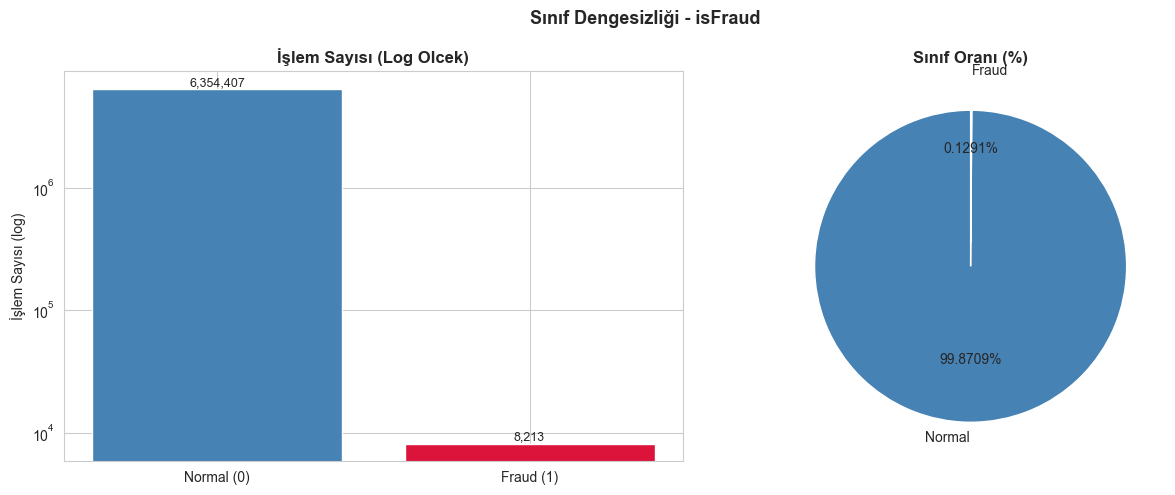

In [4]:
fraud_counts = df["isFraud"].value_counts().sort_index()
fraud_pct = df["isFraud"].value_counts(normalize=True).sort_index() * 100

print("isFraud Dağılımı:")
print(f"  Normal   (0): {fraud_counts[0]:,}  (%{fraud_pct[0]:.4f})")
print(f"  Fraud    (1): {fraud_counts[1]:,}  (%{fraud_pct[1]:.4f})")
print(f"  Dengesizlik orani = 1 : {fraud_counts[0] / fraud_counts[1]:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
bars = ax.bar(["Normal (0)", "Fraud (1)"], fraud_counts.values, color=["steelblue", "crimson"])
ax.set_yscale("log")
ax.set_title("İşlem Sayısı (Log Olcek)", fontsize=12, fontweight="bold")
ax.set_ylabel("İşlem Sayısı (log)")
for b, v in zip(bars, fraud_counts.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

ax = axes[1]
ax.pie(fraud_counts.values, labels=["Normal", "Fraud"], autopct="%1.4f%%",
       colors=["steelblue", "crimson"], explode=(0, 0.15), startangle=90)
ax.set_title("Sınıf Oranı (%)", fontsize=12, fontweight="bold")
plt.suptitle("Sınıf Dengesizliği - isFraud", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Veri setinde:

- **6.354.407 normal işlem (%99,8709)**
- **8.213 fraud işlem (%0,1291)**

bulunmaktadır. Yaklaşık olarak her **774 normal işleme karşılık yalnızca 1 fraud işlem** vardır.

Bu durum ciddi bir **sınıf dengesizliği (class imbalance)** olduğunu göstermektedir.

Bu nedenle `accuracy` tek başına güvenilir bir değerlendirme metriği değildir. Örneğin model bütün işlemleri normal olarak tahmin etse bile yaklaşık %99,87 accuracy elde edebilir; ancak hiçbir fraud işlemini yakalayamaz. Bu yüzden projenin değerlendirilmesinde özellikle **Precision, Recall, F1-Score ve PR-AUC** metriklerine odaklanılmıştır.

### 3.3 İşlem Türüne Göre Dolandırıcılık Yoğunluğu

Bu bölümde `type` değişkeni ile `isFraud` hedef değişkeni birlikte incelenmiştir. Amaç, fraud işlemlerinin tüm işlem türlerinde mi yoksa belirli işlem türlerinde mi gerçekleştiğini belirlemektir.

İşlem Türüne Göre Dolandırıcılık:
           Normal  Fraud  Fraud_Orani_%
type                                   
CASH_OUT  2233384   4116         0.1840
TRANSFER   528812   4097         0.7688
CASH_IN   1399284      0         0.0000
DEBIT       41432      0         0.0000
PAYMENT   2151495      0         0.0000


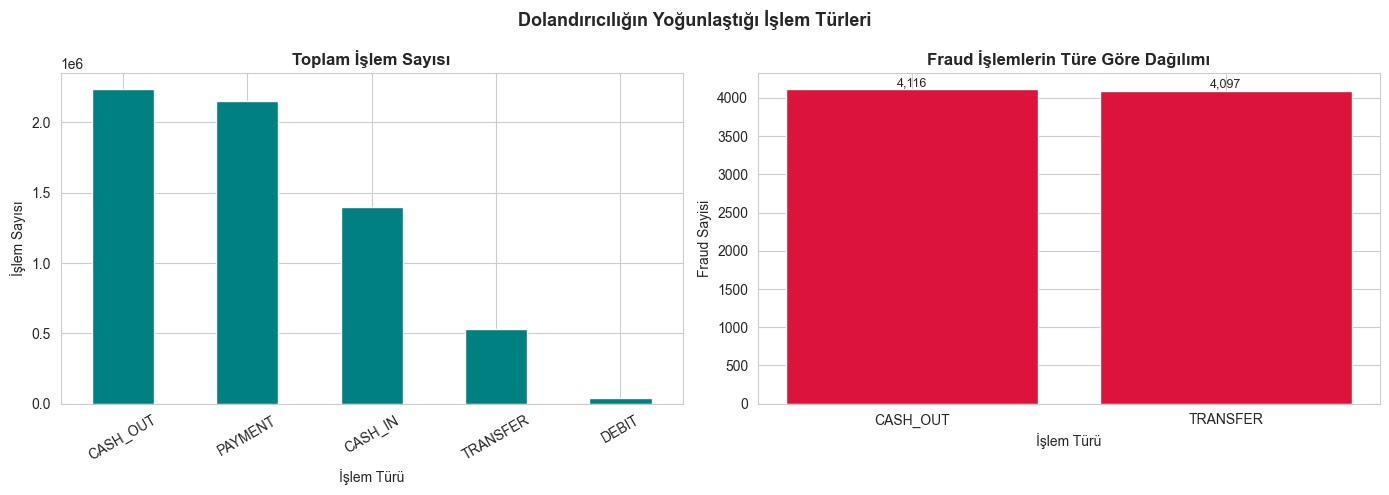

In [5]:
type_fraud = pd.crosstab(df["type"], df["isFraud"])
type_fraud.columns = ["Normal", "Fraud"]
type_fraud["Fraud_Orani_%"] = (type_fraud["Fraud"] /
                                (type_fraud["Normal"] + type_fraud["Fraud"]) * 100).round(4)
print("İşlem Türüne Göre Dolandırıcılık:")
print(type_fraud.sort_values("Fraud", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
df["type"].value_counts().plot(kind="bar", ax=ax, color="teal")
ax.set_title("Toplam İşlem Sayısı", fontsize=12, fontweight="bold")
ax.set_xlabel("İşlem Türü"); ax.set_ylabel("İşlem Sayısı")
ax.tick_params(axis="x", rotation=30)

ax = axes[1]
fraud_only = df[df["isFraud"] == 1]["type"].value_counts()
bars = ax.bar(fraud_only.index, fraud_only.values, color="crimson")
ax.set_title("Fraud İşlemlerin Türe Göre Dağılımı", fontsize=12, fontweight="bold")
ax.set_xlabel("İşlem Türü"); ax.set_ylabel("Fraud Sayisi")
for b, v in zip(bars, fraud_only.values):
    ax.text(b.get_x() + b.get_width()/2, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Dolandırıcılığın Yoğunlaştığı İşlem Türleri", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### H1 Sonucu

Fraud işlemlerinin yalnızca iki işlem türünde gerçekleştiği görülmüştür:

- **CASH_OUT:** 4.116 fraud işlem
- **TRANSFER:** 4.097 fraud işlem

`PAYMENT`, `CASH_IN` ve `DEBIT` işlem türlerinde ise veri setinde hiç fraud kaydı bulunmamaktadır.

Bu nedenle **H1 hipotezi doğrulanmıştır.**

Modelleme aşamasında yalnızca `TRANSFER` ve `CASH_OUT` işlemlerinin kullanılması tercih edilmiştir. Böylece model, fraud oluşma ihtimali bulunan işlem türlerine odaklanmıştır. Ancak bu kararın önemli bir kapsam sınırlaması vardır: geliştirilen model yalnızca bu iki işlem türü için yorumlanmalıdır.

### 3.4 İşlem Tutarlarının Analizi

Bu bölümde normal ve fraud işlemlerin `amount` dağılımları boxplot yardımıyla karşılaştırılmıştır. Finansal işlem tutarları oldukça geniş bir aralıkta olduğu için grafiklerde logaritmik ölçek kullanılmıştır.

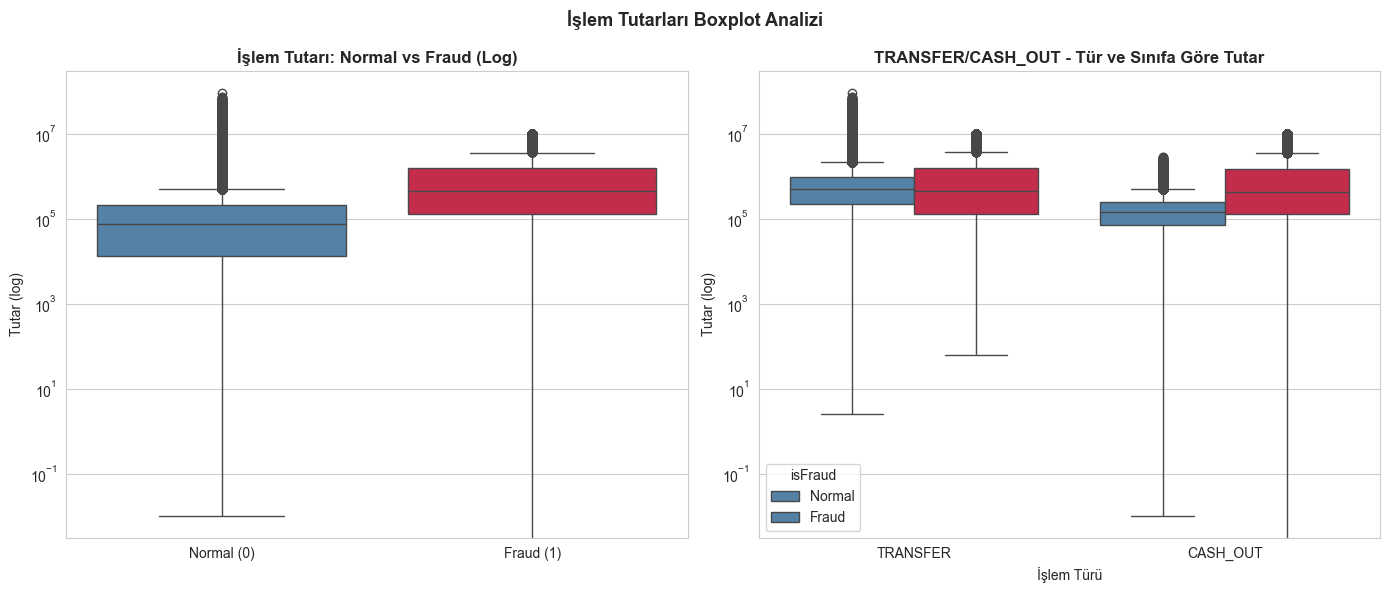

Tutar İstatistikleri:
             count        mean         std   min        25%        50%  \
isFraud                                                                  
0        6354407.0   178197.04   596236.98  0.01   13368.40   74684.72   
1           8213.0  1467967.30  2404252.95  0.00  127091.33  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
sns.boxplot(x="isFraud", y="amount", data=df, ax=ax, palette=["steelblue", "crimson"])
ax.set_yscale("log")
ax.set_xticklabels(["Normal (0)", "Fraud (1)"])
ax.set_title("İşlem Tutarı: Normal vs Fraud (Log)", fontsize=12, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel("Tutar (log)")

ax = axes[1]
subset = df[df["type"].isin(["TRANSFER", "CASH_OUT"])]
sns.boxplot(x="type", y="amount", hue="isFraud", data=subset, ax=ax,
            palette=["steelblue", "crimson"])
ax.set_yscale("log")
ax.set_title("TRANSFER/CASH_OUT - Tür ve Sınıfa Göre Tutar", fontsize=12, fontweight="bold")
ax.set_xlabel("İşlem Türü"); ax.set_ylabel("Tutar (log)")
ax.legend(title="isFraud", labels=["Normal", "Fraud"])
plt.suptitle("İşlem Tutarları Boxplot Analizi", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Tutar İstatistikleri:")
print(df.groupby("isFraud")["amount"].describe().round(2))

Fraud işlemlerinin ortalama işlem tutarı yaklaşık **1,47 milyon**, normal işlemlerin ortalama işlem tutarı ise yaklaşık **178 bin** seviyesindedir. Fraud işlemlerinin ortalama tutarı normal işlemlere göre yaklaşık **8 kat daha yüksektir**.

Bu sonuç `amount` değişkeninin fraud tespitinde önemli bir sinyal taşıyabileceğini göstermektedir. Ancak yalnızca işlem tutarına dayanarak karar vermek yeterli değildir; model diğer bakiye, zaman ve işlem davranışı özellikleriyle birlikte değerlendirme yapmaktadır.

### 3.5 Özellik Dağılımlarının Histogram ile İncelenmesi

Boxplot analizi aykırı değerleri ve sınıflar arasındaki genel farkı göstermektedir. Buna ek olarak, değişkenlerin dağılım biçimini daha ayrıntılı incelemek amacıyla histogramlar oluşturulmuştur.

PaySim veri setinde normal işlem sayısı fraud işlem sayısından çok daha fazla olduğu için grafiklerin okunabilirliğini artırmak amacıyla normal işlemlerden rastgele bir örnek alınmış, fraud işlemlerinin tamamı görselleştirmeye dahil edilmiştir. Histogramlarda **yoğunluk (density)** kullanıldığı için sınıfların farklı örnek sayıları doğrudan grafiği yanıltmamaktadır.

Özellikle işlem tutarı, gönderici hesabın işlem öncesi bakiyesi ve alıcı hesabın işlem öncesi bakiyesi normal ve fraud sınıfları arasında karşılaştırılmıştır. Finansal değişkenlerin geniş değer aralıklarına sahip olması nedeniyle logaritmik dönüşüm kullanılmıştır.

Bu analiz, fraud işlemlerinin yalnızca ortalama değer bakımından değil, **dağılım yapısı bakımından da normal işlemlerden farklılaşıp farklılaşmadığını** incelemeyi amaçlamaktadır.


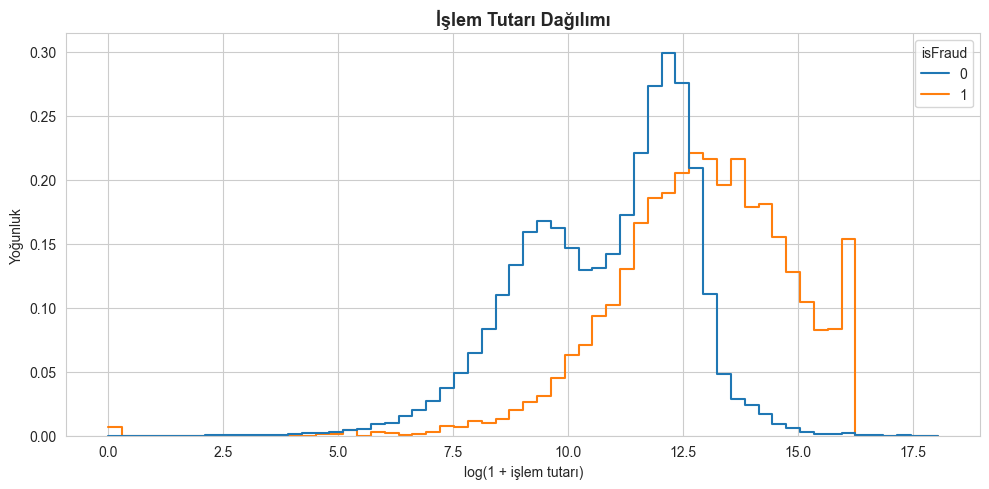

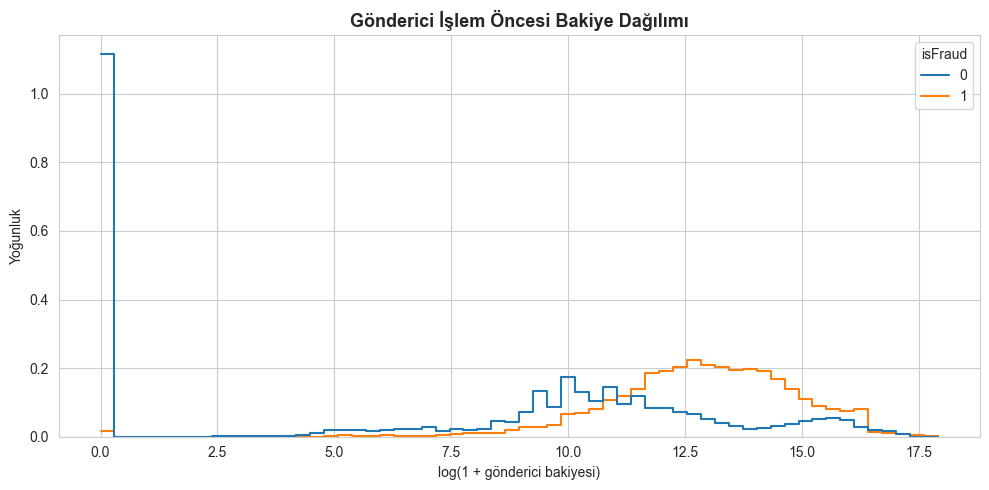

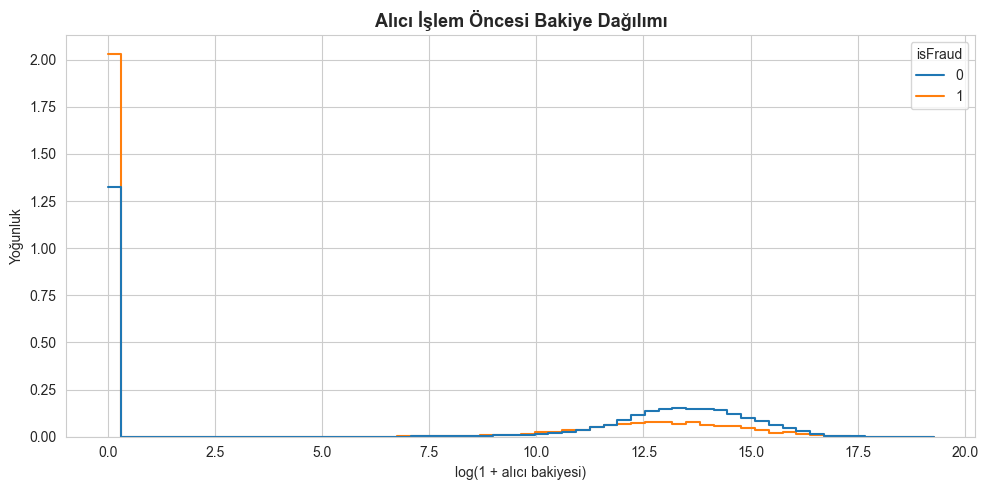

Histogram analizi tamamlandı.
Görselleştirmede 120,000 normal ve 8,213 fraud işlem kullanıldı.


In [7]:
# Özellik dağılımlarını histogram ile karşılaştır
normal_pool = df[df["isFraud"] == 0]
fraud_pool = df[df["isFraud"] == 1]

normal_sample = normal_pool.sample(
    n=min(120_000, len(normal_pool)),
    random_state=RANDOM_STATE
)
hist_df = pd.concat([normal_sample, fraud_pool], ignore_index=True).copy()

hist_df["log_amount_tmp"] = np.log1p(hist_df["amount"])
hist_df["log_oldbalanceOrg_tmp"] = np.log1p(hist_df["oldbalanceOrg"])
hist_df["log_oldbalanceDest_tmp"] = np.log1p(hist_df["oldbalanceDest"])

for column, title, xlabel in [
    ("log_amount_tmp", "İşlem Tutarı Dağılımı", "log(1 + işlem tutarı)"),
    ("log_oldbalanceOrg_tmp", "Gönderici İşlem Öncesi Bakiye Dağılımı", "log(1 + gönderici bakiyesi)"),
    ("log_oldbalanceDest_tmp", "Alıcı İşlem Öncesi Bakiye Dağılımı", "log(1 + alıcı bakiyesi)"),
]:
    plt.figure(figsize=(10, 5))
    sns.histplot(
        data=hist_df,
        x=column,
        hue="isFraud",
        bins=60,
        stat="density",
        common_norm=False,
        element="step",
        fill=False
    )
    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel(xlabel)
    plt.ylabel("Yoğunluk")
    plt.tight_layout()
    plt.show()

print("Histogram analizi tamamlandı.")
print(f"Görselleştirmede {len(normal_sample):,} normal ve {len(fraud_pool):,} fraud işlem kullanıldı.")


## 4. Feature Engineering (Yeni Özellik Üretimi)

Feature Engineering aşamasında mevcut değişkenlerden fraud davranışını daha iyi temsil edebilecek yeni değişkenler üretilmiştir.

Bu aşamadaki temel amaç, modele yalnızca ham değerleri vermek yerine işlemin finansal yapısını ve davranışsal özelliklerini daha anlamlı biçimde temsil etmektir.

EDA sonucunda fraud yalnızca `TRANSFER` ve `CASH_OUT` işlemlerinde görüldüğü için veri seti bu iki işlem türü ile sınırlandırılmıştır. Filtreleme sonrasında:

- **2.770.409 işlem**
- yaklaşık **%0,2965 fraud oranı**

elde edilmiştir.

In [8]:
print(f"Filtreleme öncesi: {len(df):,} satir")
df_fe = df[df["type"].isin(["TRANSFER", "CASH_OUT"])].copy().reset_index(drop=True)
print(f"Filtreleme sonrası: {len(df_fe):,} satir")
print(f"Yeni fraud oranı: %{df_fe['isFraud'].mean()*100:.4f}")

# ─── Islem-sonrasi degiskenler (sizinti analizi icin saklanir) ──────────
df_fe["errorBalanceOrig"] = df_fe["newbalanceOrig"] + df_fe["amount"] - df_fe["oldbalanceOrg"]
df_fe["errorBalanceDest"] = df_fe["oldbalanceDest"] + df_fe["amount"] - df_fe["newbalanceDest"]

# ─── Kategorik kodlama ──────────────────────────────────────────────────
le_type = LabelEncoder()
df_fe["type_enc"] = le_type.fit_transform(df_fe["type"])
print("Tür kodlaması:", dict(zip(le_type.classes_, le_type.transform(le_type.classes_))))

# ─── Islem-oncesi turetilmis ozellikler (sizintisiz, operasyonel) ──────

# 1) amount_ratio: tutarin gonderici bakiyesine orani
#    Fraud'da hesap tamamen bosaltilir → oran ~1.0'a yaklasir
df_fe["amount_ratio"] = df_fe["amount"] / (df_fe["oldbalanceOrg"] + 1)

# 2) amount_to_dest_ratio: tutarin alici bakiyesine orani
#    Buyuk tutar + kucuk bakiyeli alici = paravan (mule) hesap sinyali
df_fe["amount_to_dest_ratio"] = df_fe["amount"] / (df_fe["oldbalanceDest"] + 1)

# 3) is_round_amount: tutar yuvarlak bir sayi mi? (1000'in kati)
#    Dolandiricilar genelde 100K, 500K gibi yuvarlak tutarlar kullanir
df_fe["is_round_amount"] = (df_fe["amount"] % 1000 == 0).astype(int)

# 4) Zamansal ozellikler: step'ten saat ve gun cikarimi (1 step = 1 saat)
df_fe["hour_of_day"] = df_fe["step"] % 24
df_fe["day"] = df_fe["step"] // 24
df_fe["is_night"] = df_fe["hour_of_day"].isin([0, 1, 2, 3, 4, 5]).astype(int)

# 5) Dongüsel zaman kodlamasi: saat 23 ve 0 aslinda birbirine yakindir
df_fe["hour_sin"] = np.sin(2 * np.pi * df_fe["hour_of_day"] / 24)
df_fe["hour_cos"] = np.cos(2 * np.pi * df_fe["hour_of_day"] / 24)

# 6) dest_is_zero: hedef hesabin bakiyesi sifir mi? (paravan hesap gostergesi)
df_fe["dest_is_zero"] = (df_fe["oldbalanceDest"] == 0).astype(int)

# 7) log_amount: saga carpik tutar dagilimini normallestirmek icin
df_fe["log_amount"] = np.log1p(df_fe["amount"])

# 8) balance_diff: gonderici-alici bakiye farki
df_fe["balance_diff"] = df_fe["oldbalanceOrg"] - df_fe["oldbalanceDest"]

# 9) orig_has_balance: gondericinin bakiyesi var mi?
df_fe["orig_has_balance"] = (df_fe["oldbalanceOrg"] > 0).astype(int)

# ─── ANALIZ ICIN hesaplanan ama modele DAHIL EDILMEYEN ozellikler ──────
# is_full_transfer: amount == oldbalanceOrg (hesabin tamami bosaltiliyor mu?)
# remaining_balance_ratio: (oldbalanceOrg - amount) / (oldbalanceOrg + 1)
# Bu iki ozellik asagidaki analizde neden cikarildigini gostermek icin hesaplaniyor.
df_fe["is_full_transfer"] = (df_fe["amount"] == df_fe["oldbalanceOrg"]).astype(int)
df_fe["remaining_balance_ratio"] = (df_fe["oldbalanceOrg"] - df_fe["amount"]) / (df_fe["oldbalanceOrg"] + 1)

print(f"\n--- Çıkarılan Özelliklerin Analizi ---")
print(f"is_full_transfer  <-> isFraud korelasyonu: {df_fe['is_full_transfer'].corr(df_fe['isFraud']):+.4f}")
print(f"remaining_balance_ratio <-> amount_ratio korelasyonu: {df_fe['remaining_balance_ratio'].corr(df_fe['amount_ratio']):+.4f}")

used_features = ["amount_ratio", "amount_to_dest_ratio", "is_round_amount",
                 "hour_of_day", "day", "is_night", "hour_sin", "hour_cos",
                 "dest_is_zero", "log_amount", "balance_diff", "orig_has_balance"]
print(f"\nModele dahil edilen {len(used_features)} yeni özellik: {used_features}")
print(f"Modelden çıkarılan 2 ozellik: is_full_transfer (r=0.99, PaySim'e ozgu sentetik proxy/shortcut), remaining_balance_ratio (amount_ratio ile r=-1.0)")

Filtreleme öncesi: 6,362,620 satir
Filtreleme sonrası: 2,770,409 satir
Yeni fraud oranı: %0.2965
Tür kodlaması: {'CASH_OUT': np.int64(0), 'TRANSFER': np.int64(1)}

--- Çıkarılan Özelliklerin Analizi ---
is_full_transfer  <-> isFraud korelasyonu: +0.9890
remaining_balance_ratio <-> amount_ratio korelasyonu: -1.0000

Modele dahil edilen 12 yeni özellik: ['amount_ratio', 'amount_to_dest_ratio', 'is_round_amount', 'hour_of_day', 'day', 'is_night', 'hour_sin', 'hour_cos', 'dest_is_zero', 'log_amount', 'balance_diff', 'orig_has_balance']
Modelden çıkarılan 2 ozellik: is_full_transfer (r=0.99, PaySim'e ozgu sentetik proxy/shortcut), remaining_balance_ratio (amount_ratio ile r=-1.0)


### Üretilen ve Kullanılan Özellikler

Modelde işlem anında bilinebilecek **17 güvenli özellik** kullanılmıştır.

#### Orijinal işlem öncesi özellikler

- `step`
- `type_enc`
- `amount`
- `oldbalanceOrg`
- `oldbalanceDest`

#### Türetilmiş işlem öncesi özellikler

| Özellik | Açıklama |
|---|---|
| `amount_ratio` | İşlem tutarının gönderici bakiyesine oranıdır. |
| `amount_to_dest_ratio` | İşlem tutarının alıcının işlem öncesi bakiyesine oranıdır. |
| `dest_is_zero` | Alıcı hesabın işlem öncesi bakiyesinin sıfır olup olmadığını gösterir. |
| `is_round_amount` | İşlem tutarının 1.000'in katı gibi yuvarlak bir değer olup olmadığını gösterir. |
| `log_amount` | İşlem tutarının logaritmik dönüşümüdür. |
| `balance_diff` | Gönderici ve alıcının işlem öncesi bakiyeleri arasındaki farktır. |
| `orig_has_balance` | Gönderici hesabın işlem öncesinde bakiyeye sahip olup olmadığını gösterir. |
| `hour_of_day` | `step` değişkeninden türetilen saat bilgisidir. |
| `day` | `step` değişkeninden türetilen gün bilgisidir. |
| `is_night` | İşlemin gece saatlerinde gerçekleşip gerçekleşmediğini gösterir. |
| `hour_sin` / `hour_cos` | Saat bilgisini döngüsel olarak temsil eden değişkenlerdir. |

### Kategorik Değişkenin Kodlanması

Filtrelemeden sonra `type` değişkeni yalnızca `CASH_OUT` ve `TRANSFER` kategorilerini içermektedir. Bu kategorik değişken `LabelEncoder` kullanılarak sayısal hale getirilmiştir.

### Modelden Bilinçli Olarak Çıkarılan Özellikler

`is_full_transfer`, işlem tutarının gönderici bakiyesine tam olarak eşit olup olmadığını göstermektedir. Bu özellik `isFraud` ile yaklaşık **0,989 korelasyona** sahiptir. Ancak bu ilişki PaySim'in sentetik fraud üretim mekanizmasına çok yakın olduğu için gerçek hayata genellenebilirliği zayıf bir **proxy/shortcut özellik** olarak değerlendirilmiş ve modele dahil edilmemiştir.

`remaining_balance_ratio` ise `amount_ratio` ile neredeyse tam ters yönde aynı bilgiyi taşımaktadır (`r ≈ -1`). Tekrarlı bilgi yaratmamak amacıyla modelden çıkarılmıştır.

### İşlem Sonrası ve Veri Sızıntısı Oluşturabilecek Değişkenler

Aşağıdaki dört özellik ana operasyonel modelde kullanılmamıştır:

- `newbalanceOrig`
- `newbalanceDest`
- `errorBalanceOrig`
- `errorBalanceDest`

Bu değişkenler işlemin gerçekleşmesinden sonraki bakiye bilgisini içerdiği için gerçek zamanlı fraud tahmininde kullanılması **veri sızıntısı (data leakage)** oluşturabilir. Bu nedenle yalnızca Bölüm 10'daki kontrollü sızıntı deneyinde kullanılmıştır.

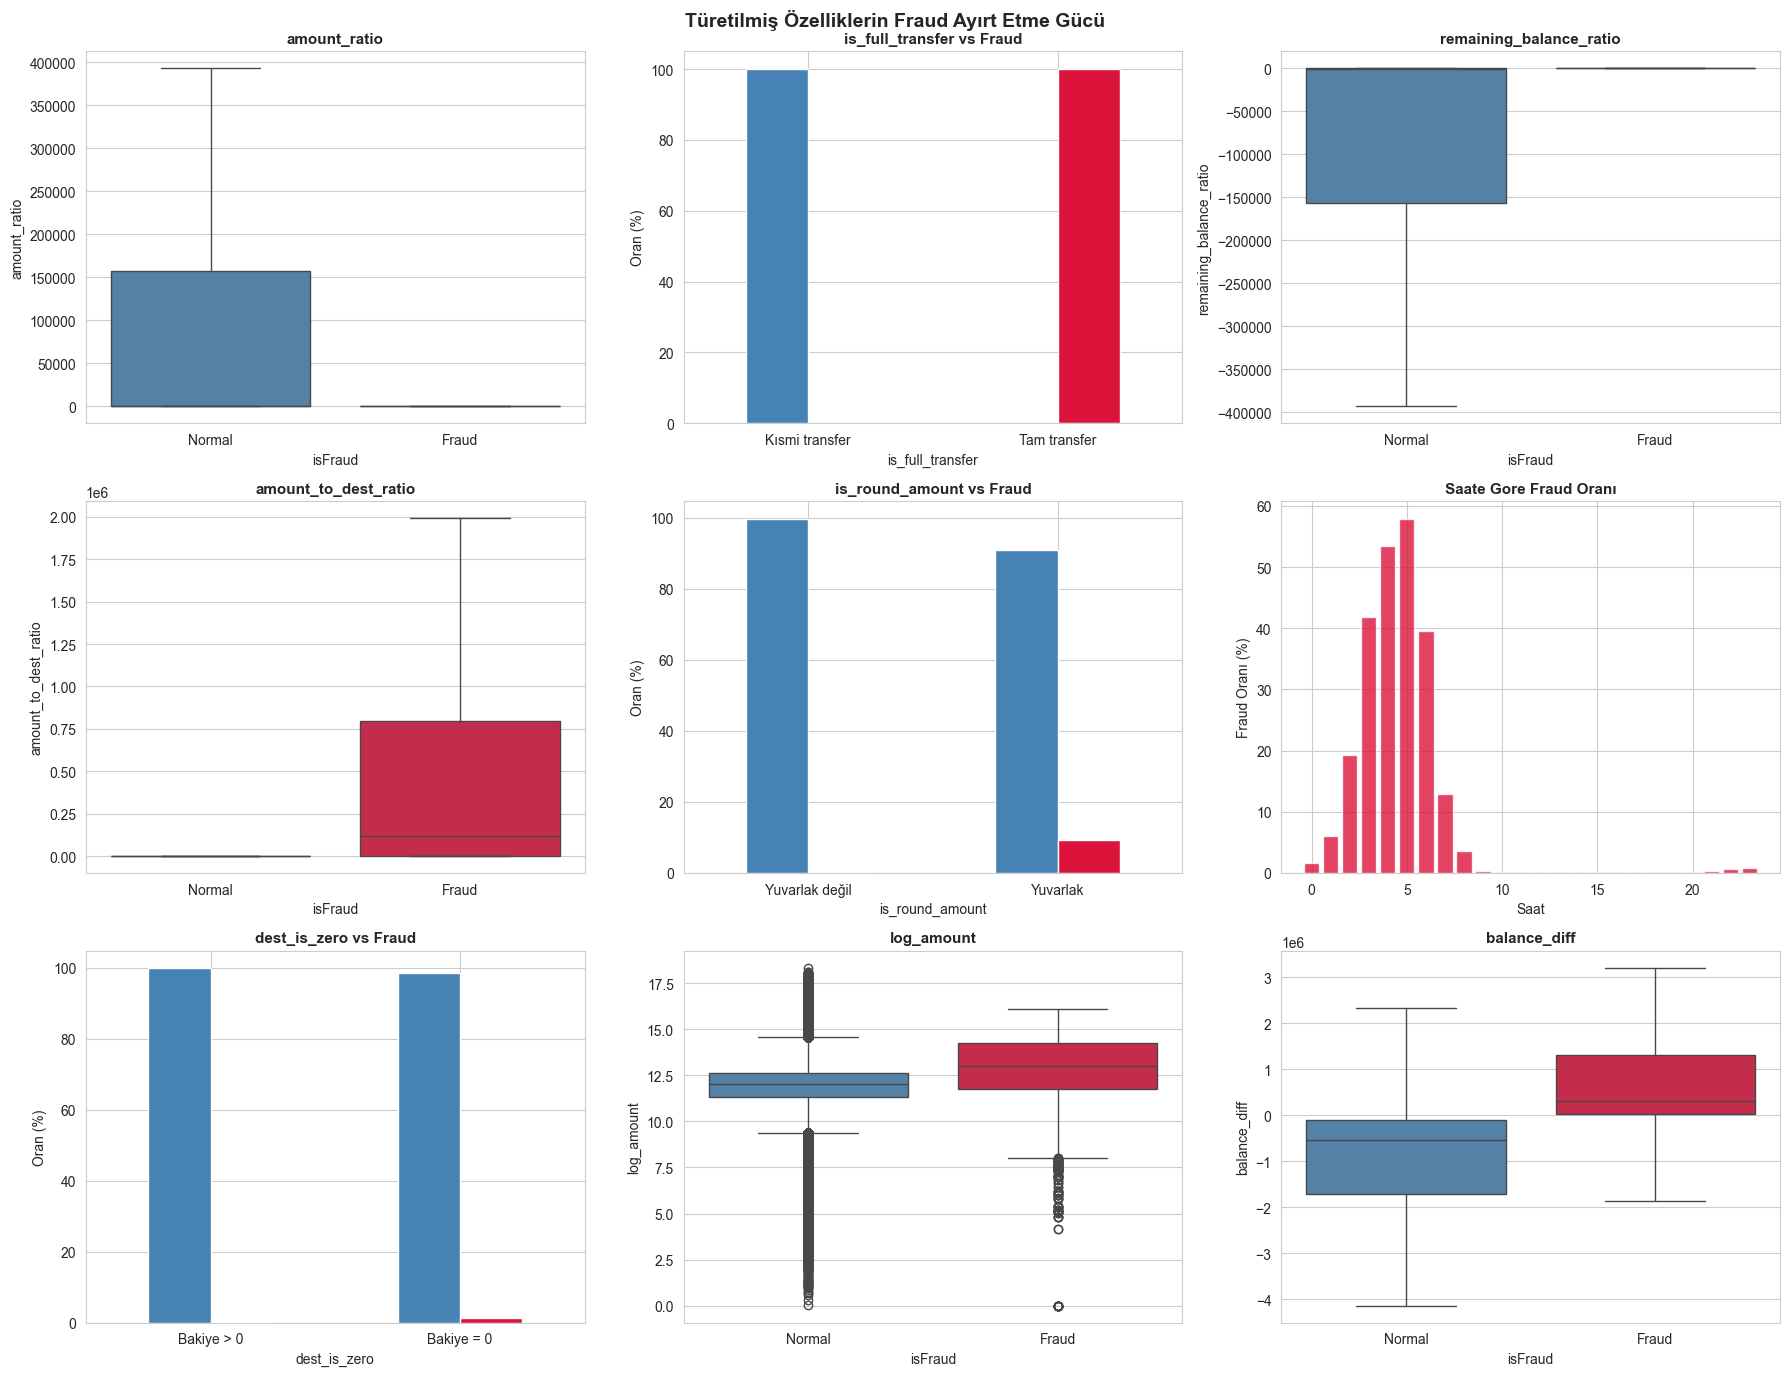


Yeni özelliklerin isFraud ile korelasyonu (point-biserial):
  amount_ratio                : -0.0112
  is_full_transfer            : +0.9890
  remaining_balance_ratio     : +0.0112
  amount_to_dest_ratio        : +0.1810
  is_round_amount             : +0.0566
  dest_is_zero                : +0.0802
  log_amount                  : +0.0426
  balance_diff                : +0.0355
  is_night                    : +0.1268
  orig_has_balance            : +0.0510

En güçlü korelasyon: is_full_transfer (+0.9890)


In [9]:
# ─── Yeni ozelliklerin fraud ayirt etme gucunu gorsellestir ────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 1) amount_ratio
ax = axes[0, 0]
sns.boxplot(x="isFraud", y="amount_ratio", data=df_fe, ax=ax,
            palette=["steelblue", "crimson"], showfliers=False)
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("amount_ratio", fontsize=11, fontweight="bold")

# 2) is_full_transfer
ax = axes[0, 1]
ft_fraud = pd.crosstab(df_fe["is_full_transfer"], df_fe["isFraud"], normalize="index") * 100
ft_fraud.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], legend=False)
ax.set_xticklabels(["Kısmi transfer", "Tam transfer"], rotation=0)
ax.set_ylabel("Oran (%)")
ax.set_title("is_full_transfer vs Fraud", fontsize=11, fontweight="bold")

# 3) remaining_balance_ratio
ax = axes[0, 2]
sns.boxplot(x="isFraud", y="remaining_balance_ratio", data=df_fe, ax=ax,
            palette=["steelblue", "crimson"], showfliers=False)
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("remaining_balance_ratio", fontsize=11, fontweight="bold")

# 4) amount_to_dest_ratio
ax = axes[1, 0]
sns.boxplot(x="isFraud", y="amount_to_dest_ratio", data=df_fe, ax=ax,
            palette=["steelblue", "crimson"], showfliers=False)
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("amount_to_dest_ratio", fontsize=11, fontweight="bold")

# 5) is_round_amount
ax = axes[1, 1]
round_fraud = pd.crosstab(df_fe["is_round_amount"], df_fe["isFraud"], normalize="index") * 100
round_fraud.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], legend=False)
ax.set_xticklabels(["Yuvarlak değil", "Yuvarlak"], rotation=0)
ax.set_ylabel("Oran (%)")
ax.set_title("is_round_amount vs Fraud", fontsize=11, fontweight="bold")

# 6) hour_of_day fraud oranı
ax = axes[1, 2]
fraud_hours = df_fe[df_fe["isFraud"]==1]["hour_of_day"].value_counts().sort_index()
normal_hours = df_fe[df_fe["isFraud"]==0]["hour_of_day"].value_counts().sort_index()
fraud_pct_hour = fraud_hours / (fraud_hours + normal_hours) * 100
ax.bar(fraud_pct_hour.index, fraud_pct_hour.values, color="crimson", alpha=0.8)
ax.set_xlabel("Saat")
ax.set_ylabel("Fraud Oranı (%)")
ax.set_title("Saate Gore Fraud Oranı", fontsize=11, fontweight="bold")

# 7) dest_is_zero
ax = axes[2, 0]
dest_fraud = pd.crosstab(df_fe["dest_is_zero"], df_fe["isFraud"], normalize="index") * 100
dest_fraud.plot(kind="bar", ax=ax, color=["steelblue", "crimson"], legend=False)
ax.set_xticklabels(["Bakiye > 0", "Bakiye = 0"], rotation=0)
ax.set_ylabel("Oran (%)")
ax.set_title("dest_is_zero vs Fraud", fontsize=11, fontweight="bold")

# 8) log_amount
ax = axes[2, 1]
sns.boxplot(x="isFraud", y="log_amount", data=df_fe, ax=ax,
            palette=["steelblue", "crimson"])
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("log_amount", fontsize=11, fontweight="bold")

# 9) balance_diff
ax = axes[2, 2]
sns.boxplot(x="isFraud", y="balance_diff", data=df_fe, ax=ax,
            palette=["steelblue", "crimson"], showfliers=False)
ax.set_xticklabels(["Normal", "Fraud"])
ax.set_title("balance_diff", fontsize=11, fontweight="bold")

plt.suptitle("Türetilmiş Özelliklerin Fraud Ayırt Etme Gücü", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ─── Korelasyon tablosu ──────────────────────────────────────────────────
new_feats = ["amount_ratio", "is_full_transfer", "remaining_balance_ratio",
             "amount_to_dest_ratio", "is_round_amount", "dest_is_zero",
             "log_amount", "balance_diff", "is_night", "orig_has_balance"]
print("\nYeni özelliklerin isFraud ile korelasyonu (point-biserial):")
corr_list = []
for f in new_feats:
    corr = df_fe[f].corr(df_fe["isFraud"])
    corr_list.append((f, corr))
    print(f"  {f:28s}: {corr:+.4f}")
corr_list.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"\nEn güçlü korelasyon: {corr_list[0][0]} ({corr_list[0][1]:+.4f})")

### Feature Engineering Sonucu

Görsel analizde özellikle `is_full_transfer` ve `amount_ratio` değişkenlerinin fraud sınıfını güçlü biçimde ayırdığı görülmüştür.

Buna rağmen `is_full_transfer` modele dahil edilmemiştir; çünkü PaySim'in sentetik fraud oluşturma kuralına aşırı yakın bir sinyal taşımaktadır. Böyle bir değişken veri seti üzerinde çok yüksek sonuç verebilir ancak gerçek finansal işlemlerde aynı ilişki bulunmayabilir.

`amount_ratio` ise işlem anında hesaplanabildiği ve finansal olarak anlamlı olduğu için operasyonel özellik setinde tutulmuştur.

Ayrıca düşük Pearson korelasyonu, bir değişken ile fraud arasında ilişki olmadığı anlamına gelmez. Random Forest ve LightGBM gibi ağaç tabanlı modeller doğrusal olmayan ilişkileri de öğrenebildiği için korelasyon tablosu yalnızca yardımcı bir analiz olarak değerlendirilmiştir.

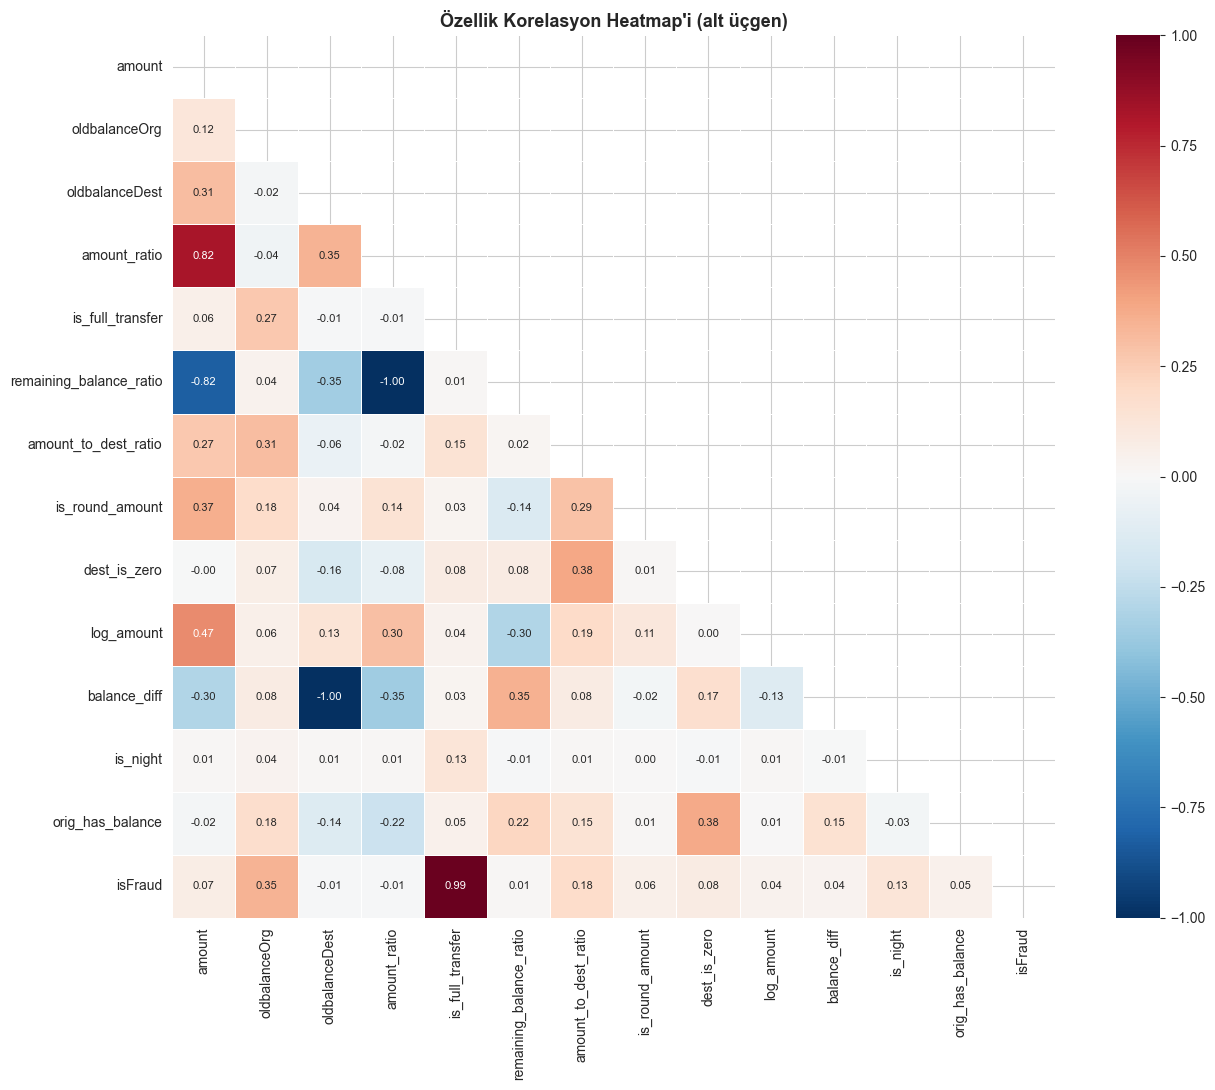

Yüksek korelasyonlu özellik çiftleri (|r| > 0.5):
  amount                       <-> amount_ratio                : +0.821
  amount                       <-> remaining_balance_ratio     : -0.821
  oldbalanceDest               <-> balance_diff                : -0.998
  amount_ratio                 <-> remaining_balance_ratio     : -1.000


In [10]:
# ─── Feature Interaction: Korelasyon Heatmap ─────────────────────────────
corr_cols = ["amount", "oldbalanceOrg", "oldbalanceDest", "amount_ratio",
             "is_full_transfer", "remaining_balance_ratio", "amount_to_dest_ratio",
             "is_round_amount", "dest_is_zero", "log_amount", "balance_diff",
             "is_night", "orig_has_balance", "isFraud"]

corr_matrix = df_fe[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Özellik Korelasyon Heatmap'i (alt üçgen)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# En yuksek korelasyonlu ciftleri raporla (isFraud haric, mutlak deger > 0.5)
print("Yüksek korelasyonlu özellik çiftleri (|r| > 0.5):")
for i in range(len(corr_cols)-1):
    for j in range(i+1, len(corr_cols)-1):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"  {corr_cols[i]:28s} <-> {corr_cols[j]:28s}: {r:+.3f}")

### Korelasyon Analizinin Yorumu

Korelasyon heatmap'i özellikler arasında güçlü doğrusal ilişkiler bulunup bulunmadığını incelemek amacıyla oluşturulmuştur.

Mutlak korelasyon değeri yüksek olan özellikler benzer bilgiyi taşıyabilir. Ağaç tabanlı modeller çoklu doğrusal bağlantıdan lineer modellere göre daha az etkilenir; ancak birbirini tekrar eden değişkenler model yorumlanabilirliğini azaltabilir.

Bu nedenle `remaining_balance_ratio` gibi doğrudan başka bir özellik ile aynı bilgiyi taşıyan değişkenler modelden çıkarılmıştır.

### 4.1 Özellik Etkileşimi (Feature Interaction) Analizi

Korelasyon analizi iki değişken arasındaki doğrusal ilişkiyi gösterir; ancak bir değişkenin fraud üzerindeki etkisi başka bir değişkenin seviyesine göre değişebilir. Bu nedenle ayrıca **özellik etkileşimi (feature interaction)** analizi yapılmıştır.

Bu analizde `amount_ratio` ile işlem türü (`TRANSFER` / `CASH_OUT`) birlikte değerlendirilmiştir. `amount_ratio`, işlem tutarının göndericinin işlem öncesi bakiyesine oranını göstermektedir.

Amaç, aynı `amount_ratio` seviyesinde farklı işlem türlerinin fraud riskinin değişip değişmediğini incelemektir. Böylece iki özelliğin **birlikte oluşturduğu koşullu fraud oranı** değerlendirilmiştir.

Random Forest ve LightGBM gibi ağaç tabanlı modeller bu tür doğrusal olmayan etkileşimleri manuel olarak yeni bir çarpım değişkeni oluşturmadan öğrenebilmektedir.


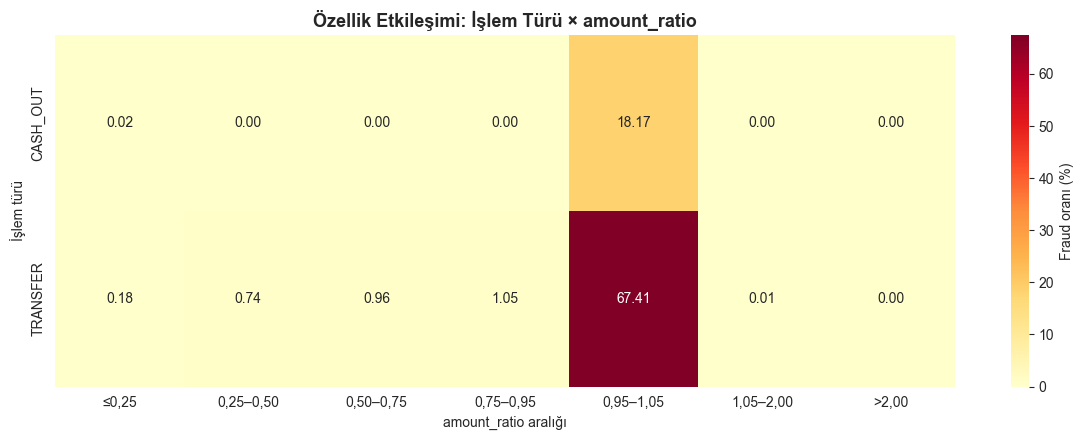

İşlem türü × amount_ratio etkileşim tablosu:


,type,amount_ratio_aralığı,count,fraud_oranı_%
0,CASH_OUT,"≤0,25",76366,0.0223
1,CASH_OUT,"0,25–0,50",68904,0.0000
2,CASH_OUT,"0,50–0,75",58070,0.0000
3,CASH_OUT,"0,75–0,95",39666,0.0000
4,CASH_OUT,"0,95–1,05",22425,18.1717
5,CASH_OUT,"1,05–2,00",132189,0.0000
6,CASH_OUT,">2,00",1839880,0.0013
7,TRANSFER,"≤0,25",5666,0.1765
8,TRANSFER,"0,25–0,50",5688,0.7384
9,TRANSFER,"0,50–0,75",5127,0.9557


In [11]:
# amount_ratio × işlem türü etkileşim analizi
interaction_df = df_fe[["type", "amount_ratio", "isFraud"]].copy()

ratio_bins = [-np.inf, 0.25, 0.50, 0.75, 0.95, 1.05, 2.00, np.inf]
ratio_labels = [
    "≤0,25", "0,25–0,50", "0,50–0,75", "0,75–0,95",
    "0,95–1,05", "1,05–2,00", ">2,00"
]

interaction_df["amount_ratio_aralığı"] = pd.cut(
    interaction_df["amount_ratio"],
    bins=ratio_bins,
    labels=ratio_labels,
    include_lowest=True
)

interaction_table = (
    interaction_df
    .groupby(["type", "amount_ratio_aralığı"], observed=True)["isFraud"]
    .agg(["mean", "count"])
    .reset_index()
)
interaction_table["fraud_oranı_%"] = interaction_table["mean"] * 100

heatmap_data = interaction_table.pivot(
    index="type",
    columns="amount_ratio_aralığı",
    values="fraud_oranı_%"
)

plt.figure(figsize=(12, 4.5))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    cbar_kws={"label": "Fraud oranı (%)"}
)
plt.title("Özellik Etkileşimi: İşlem Türü × amount_ratio", fontsize=13, fontweight="bold")
plt.xlabel("amount_ratio aralığı")
plt.ylabel("İşlem türü")
plt.tight_layout()
plt.show()

print("İşlem türü × amount_ratio etkileşim tablosu:")
display(
    interaction_table[
        ["type", "amount_ratio_aralığı", "count", "fraud_oranı_%"]
    ].round({"fraud_oranı_%": 4})
)


#### Etkileşim Analizinin Yorumu

Grafikte her hücre, belirli bir işlem türü ile belirli bir `amount_ratio` aralığının birlikte görüldüğü işlemlerdeki fraud oranını göstermektedir.

Aynı `amount_ratio` aralığında `TRANSFER` ve `CASH_OUT` satırlarının farklı fraud oranlarına sahip olması, işlem türünün `amount_ratio` etkisini değiştirebildiğini gösterir. Bu sonuç, fraud davranışının yalnızca tek tek değişkenlerden değil, değişkenler arasındaki **etkileşimlerden** de etkilenebileceğini göstermektedir.


In [12]:
SAFE_FEATURES = [
    # Orijinal islem-oncesi ozellikler
    "step", "type_enc", "amount", "oldbalanceOrg", "oldbalanceDest",
    # Bakiye analizi
    "amount_ratio",
    # Alici analizi
    "amount_to_dest_ratio", "dest_is_zero",
    # Davranissal
    "is_round_amount", "log_amount", "balance_diff", "orig_has_balance",
    # Zamansal
    "hour_of_day", "day", "is_night", "hour_sin", "hour_cos"
]
ALL_FEATURES = SAFE_FEATURES + ["newbalanceOrig", "newbalanceDest", "errorBalanceOrig", "errorBalanceDest"]

# ─── ZAMANSAL SIRALAMA VE SPLIT ─────────────────────────────────────────
df_sorted = df_fe.sort_values("step").reset_index(drop=True)

# Step SINIRLARINA gore bolme: ayni step degerindeki islemler
# ayni sette kalir — boylece zamansal sizinti onlenir.
max_step = df_sorted["step"].max()
train_step = int(max_step * 0.70)
val_step = int(max_step * 0.85)

train_mask = df_sorted["step"] <= train_step
val_mask = (df_sorted["step"] > train_step) & (df_sorted["step"] <= val_step)
test_mask = df_sorted["step"] > val_step

X_full = df_sorted[ALL_FEATURES]
X_safe = df_sorted[SAFE_FEATURES]
y = df_sorted["isFraud"]

X_train, X_val, X_test = X_full[train_mask], X_full[val_mask], X_full[test_mask]
Xs_train, Xs_val, Xs_test = X_safe[train_mask], X_safe[val_mask], X_safe[test_mask]
y_train, y_val, y_test = y[train_mask], y[val_mask], y[test_mask]

print(f"Step sınırları: train <= {train_step} | val ({train_step+1}-{val_step}) | test > {val_step}")
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:12s}: {len(yy):,} satir | fraud oranı: %{yy.mean()*100:.4f}")

print(f"\nGüvenli özellikler ({len(SAFE_FEATURES)} adet)")
print(f"Tam özellikler  ({len(ALL_FEATURES)} adet)")

Step sınırları: train <= 520 | val (521-631) | test > 631
Train       : 2,653,729 satir | fraud oranı: %0.2178
Validation  : 78,701 satir | fraud oranı: %1.4993
Test        : 37,979 satir | fraud oranı: %3.2966

Güvenli özellikler (17 adet)
Tam özellikler  (21 adet)


## 5. Zamansal Train–Validation–Test Ayrımı

Finansal fraud problemlerinde gelecekte gerçekleşecek işlemleri tahmin etmek amaçlandığı için veri **rastgele değil, zamana göre** bölünmüştür.

PaySim'de `step` değişkeni zamanı temsil etmektedir. Maksimum step değerinin yaklaşık:

- ilk **%70'lik zaman aralığı → Train**
- sonraki **%15'lik zaman aralığı → Validation**
- son **%15'lik zaman aralığı → Test**

olarak ayrılması hedeflenmiştir.

Aynı `step` değerine sahip işlemlerin farklı setlere dağılmaması için sınırlar doğrudan step değerleri üzerinden uygulanmıştır.

### Oluşan Gerçek Satır Sayıları

| Set | Satır Sayısı | Fraud Oranı |
|---|---:|---:|
| Train | 2.653.729 | %0,2178 |
| Validation | 78.701 | %1,4993 |
| Test | 37.979 | %3,2966 |

Burada önemli bir nokta vardır: **%70–%15–%15 oranı satır sayısını değil zaman aralığını ifade etmektedir.** İşlem yoğunluğu zaman boyunca eşit olmadığı için gerçek satır oranları farklı oluşmuştur.

Fraud oranının train setinde %0,2178 iken test setinde %3,2966'ya yükselmesi, zaman içerisinde belirgin bir **dağılım değişimi (distribution shift)** olduğunu göstermektedir. Bu nedenle zamansal split, rastgele split'e göre daha gerçekçi bir değerlendirme sağlamaktadır.

Ana operasyonel modelde toplam **17 işlem öncesi özellik**, sızıntı deneyinde ise işlem sonrası dört değişken de eklenerek toplam **21 özellik** kullanılmıştır.

In [13]:
# --- Random Forest ---
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=12, class_weight="balanced",
    n_jobs=-1, random_state=RANDOM_STATE
)
rf_model.fit(Xs_train, y_train)
rf_val_proba = rf_model.predict_proba(Xs_val)[:, 1]
rf_val_pred = (rf_val_proba >= 0.50).astype(int)
rf_pr_auc = average_precision_score(y_val, rf_val_proba)

print("Random Forest - Validation (SAFE_FEATURES):")
print(classification_report(y_val, rf_val_pred, target_names=["Normal", "Fraud"], digits=4))
print(f"PR-AUC: {rf_pr_auc:.4f}\n")

# --- LightGBM ---
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.1f}")

lgb_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=8, num_leaves=31,
    subsample=0.8, subsample_freq=1,
    scale_pos_weight=scale_pos_weight, boost_from_average=False,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
lgb_model.fit(Xs_train, y_train)
lgb_val_proba = lgb_model.predict_proba(Xs_val)[:, 1]
lgb_val_pred = (lgb_val_proba >= 0.50).astype(int)
lgb_pr_auc = average_precision_score(y_val, lgb_val_proba)

print("\nLightGBM - Validation (SAFE_FEATURES):")
print(classification_report(y_val, lgb_val_pred, target_names=["Normal", "Fraud"], digits=4))
print(f"PR-AUC: {lgb_pr_auc:.4f}\n")

# --- Isolation Forest ---
iso_model = IsolationForest(
    n_estimators=200, contamination=y_train.mean(), max_samples="auto",
    random_state=RANDOM_STATE, n_jobs=-1
)
iso_model.fit(Xs_train)
iso_val_scores = -iso_model.score_samples(Xs_val)
iso_val_pred = np.where(iso_model.predict(Xs_val) == -1, 1, 0)
iso_pr_auc = average_precision_score(y_val, iso_val_scores)

print("Isolation Forest - Validation (SAFE_FEATURES):")
print(classification_report(y_val, iso_val_pred, target_names=["Normal", "Fraud"], digits=4))
print(f"PR-AUC: {iso_pr_auc:.4f}")

Random Forest - Validation (SAFE_FEATURES):
              precision    recall  f1-score   support

      Normal     1.0000    0.9999    1.0000     77521
       Fraud     0.9966    1.0000    0.9983      1180

    accuracy                         0.9999     78701
   macro avg     0.9983    1.0000    0.9991     78701
weighted avg     0.9999    0.9999    0.9999     78701

PR-AUC: 1.0000

scale_pos_weight = 458.0

LightGBM - Validation (SAFE_FEATURES):
              precision    recall  f1-score   support

      Normal     0.9998    0.9983    0.9991     77521
       Fraud     0.8983    0.9881    0.9411      1180

    accuracy                         0.9981     78701
   macro avg     0.9491    0.9932    0.9701     78701
weighted avg     0.9983    0.9981    0.9982     78701

PR-AUC: 0.9870

Isolation Forest - Validation (SAFE_FEATURES):
              precision    recall  f1-score   support

      Normal     0.9894    0.9972    0.9933     77521
       Fraud     0.6169    0.2975    0.4014      

Model Karşılaştırma (Validation, SAFE_FEATURES, esik=0.50):
                  Precision  Recall  F1-Score  PR-AUC
Model                                                
Random Forest        0.9966  1.0000    0.9983   1.000
LightGBM             0.8983  0.9881    0.9411   0.987
Isolation Forest     0.6169  0.2975    0.4014   0.410


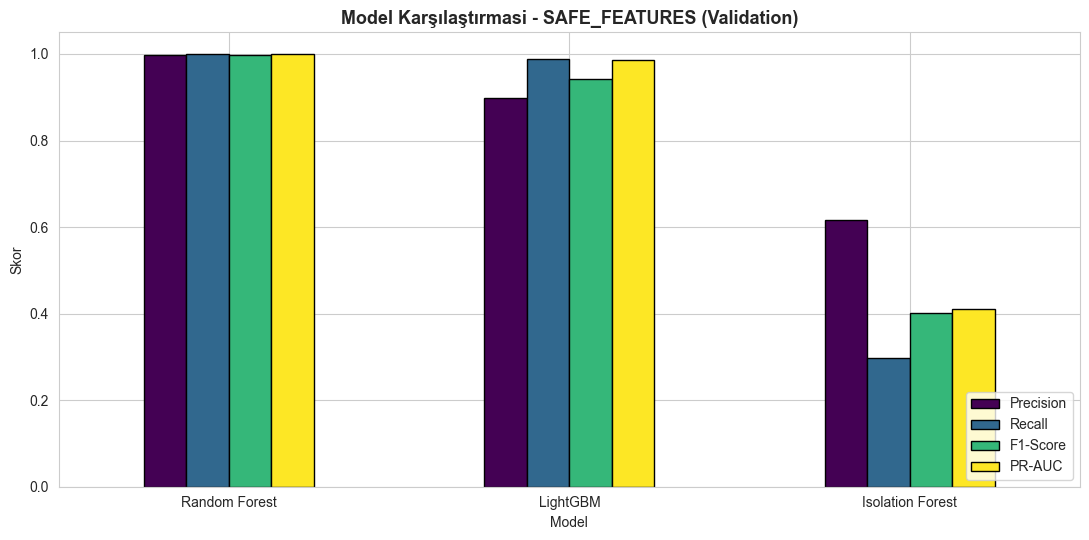

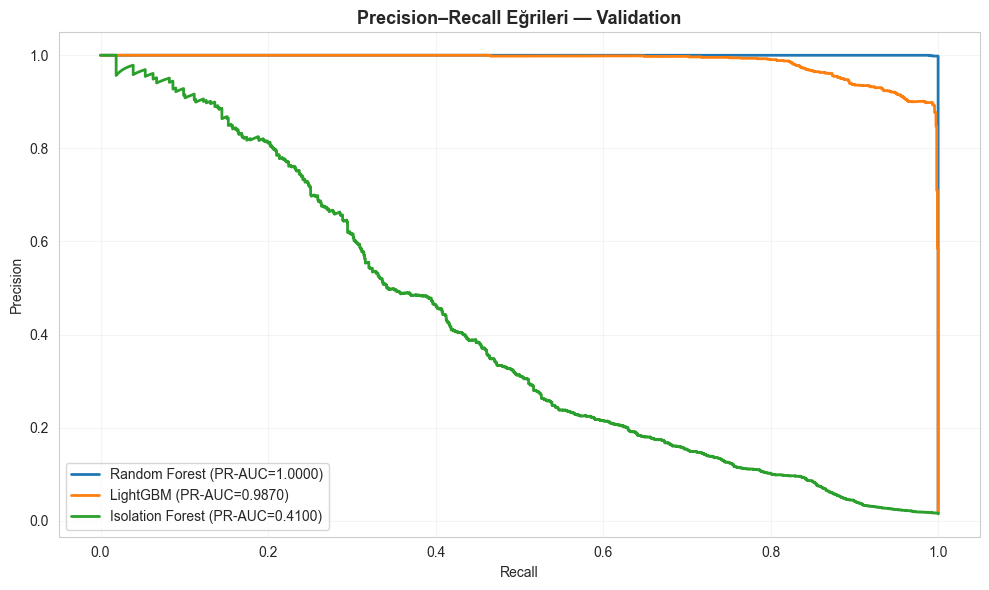

Not: Isolation Forest gözetimsiz olduğu için olasılık yerine anomali skoru kullanılmıştır.


In [14]:
def summarize(name, y_true, y_pred, y_score):
    return {"Model": name,
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1-Score": f1_score(y_true, y_pred, zero_division=0),
            "PR-AUC": average_precision_score(y_true, y_score)}

comparison = pd.DataFrame([
    summarize("Random Forest", y_val, rf_val_pred, rf_val_proba),
    summarize("LightGBM", y_val, lgb_val_pred, lgb_val_proba),
    summarize("Isolation Forest", y_val, iso_val_pred, iso_val_scores),
]).set_index("Model").round(4)

print("Model Karşılaştırma (Validation, SAFE_FEATURES, esik=0.50):")
print(comparison)

fig, ax = plt.subplots(figsize=(11, 5.5))
comparison[["Precision", "Recall", "F1-Score", "PR-AUC"]].plot(
    kind="bar", ax=ax, colormap="viridis", edgecolor="black")
ax.set_title("Model Karşılaştırmasi - SAFE_FEATURES (Validation)", fontsize=13, fontweight="bold")
ax.set_ylabel("Skor"); ax.set_xticklabels(comparison.index, rotation=0)
ax.legend(loc="lower right"); ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()
# Precision–Recall eğrileri: üç modelin validation karşılaştırması
plt.figure(figsize=(10, 6))

rf_prec_v, rf_rec_v, _ = precision_recall_curve(y_val, rf_val_proba)
lgb_prec_v, lgb_rec_v, _ = precision_recall_curve(y_val, lgb_val_proba)
iso_prec_v, iso_rec_v, _ = precision_recall_curve(y_val, iso_val_scores)

plt.plot(rf_rec_v, rf_prec_v, linewidth=2, label=f"Random Forest (PR-AUC={rf_pr_auc:.4f})")
plt.plot(lgb_rec_v, lgb_prec_v, linewidth=2, label=f"LightGBM (PR-AUC={lgb_pr_auc:.4f})")
plt.plot(iso_rec_v, iso_prec_v, linewidth=2, label=f"Isolation Forest (PR-AUC={iso_pr_auc:.4f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Eğrileri — Validation", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print("Not: Isolation Forest gözetimsiz olduğu için olasılık yerine anomali skoru kullanılmıştır.")


## 6. Model Karşılaştırması

Bu projede üç farklı yaklaşım karşılaştırılmıştır:

### Random Forest

Random Forest, çok sayıda karar ağacının birlikte çalıştığı gözetimli bir ensemble algoritmasıdır. Doğrusal olmayan ilişkileri yakalayabilir ve finansal özellikler arasındaki karmaşık etkileşimleri öğrenebilir.

Sınıf dengesizliği nedeniyle `class_weight="balanced"` kullanılmıştır. Böylece azınlık sınıfı olan fraud işlemlerine eğitim sırasında daha fazla ağırlık verilmiştir.

### LightGBM

LightGBM, gradient boosting tabanlı ve özellikle büyük veri setlerinde yüksek hız sağlayan güçlü bir sınıflandırma algoritmasıdır. PaySim veri setinin milyonlarca satır içermesi nedeniyle LightGBM operasyonel açıdan önemli bir adaydır.

Fraud sınıfının azlığı nedeniyle `scale_pos_weight` kullanılarak sınıf dengesizliği dikkate alınmıştır.

### Isolation Forest

Isolation Forest gözetimsiz bir anomali tespit algoritmasıdır. Fraud etiketini doğrudan öğrenmek yerine normal örneklerden farklı davranan işlemleri anomali olarak belirlemeye çalışır.

Bu modelin projeye dahil edilmesinin amacı, fraud probleminin yalnızca gözetimli sınıflandırma ile değil, anomali tespiti yaklaşımıyla da nasıl sonuç verdiğini karşılaştırmaktır.

### Validation Sonuçları

- **Random Forest PR-AUC: 1,0000**
- **LightGBM PR-AUC: 0,9870**
- **Isolation Forest PR-AUC: 0,4100**

Random Forest validation setinde en yüksek performansı göstermiştir. LightGBM de oldukça güçlü sonuç verirken, Isolation Forest fraud işlemlerini ayırmada belirgin biçimde daha düşük performans göstermiştir.

Bu sonuç **H3 hipotezini desteklemektedir:** etiket bilgisini kullanan gözetimli modeller, bu veri setinde gözetimsiz anomali tespit yaklaşımından daha başarılıdır.

## 7. Optuna ile Hiperparametre Optimizasyonu

LightGBM modelinin performansını geliştirmek amacıyla **Optuna** kullanılmıştır.

Hiperparametreler, modelin eğitim davranışını belirleyen ancak model tarafından doğrudan öğrenilmeyen ayarlardır. Örneğin:

- `n_estimators`
- `learning_rate`
- `max_depth`
- `num_leaves`
- `min_child_samples`
- `subsample`
- `colsample_bytree`
- `reg_alpha`
- `reg_lambda`

Optuna toplam **25 farklı deneme (trial)** gerçekleştirmiş ve her denemede farklı bir hiperparametre kombinasyonu test etmiştir.

Optimizasyon hedefi olarak **validation PR-AUC** seçilmiştir. Test seti bu süreçte kesinlikle kullanılmamıştır. Böylece test setinin final performansı tarafsız biçimde ölçmesi sağlanmıştır.

Optuna sonrasında LightGBM'in validation PR-AUC değeri yaklaşık **0,9940** seviyesine yükselmiştir.

In [15]:
def objective(trial):
    max_depth = trial.suggest_int("max_depth", 4, 12)
    max_leaves_allowed = min(255, 2 ** max_depth - 1)
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 150, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 15, max(16, max_leaves_allowed)),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "scale_pos_weight": scale_pos_weight,
        "boost_from_average": False,
        "random_state": RANDOM_STATE, "n_jobs": -1, "verbose": -1,
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(Xs_train, y_train)          # SAFE_FEATURES ile egitim
    val_proba = model.predict_proba(Xs_val)[:, 1]
    return average_precision_score(y_val, val_proba)

study = optuna.create_study(direction="maximize",
                             sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=25, show_progress_bar=False)

print("En iyi validation PR-AUC:", round(study.best_value, 4))
print("En iyi parametreler:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

En iyi validation PR-AUC: 0.994
En iyi parametreler:
   max_depth: 6
   n_estimators: 184
   learning_rate: 0.07766184280392888
   num_leaves: 36
   min_child_samples: 16
   subsample: 0.798070764044508
   colsample_bytree: 0.6137554084460873
   reg_alpha: 4.33792069749094
   reg_lambda: 0.010842262717330166


Optuna optimizasyonu yalnızca **17 güvenli operasyonel özellik** ve validation seti kullanılarak gerçekleştirilmiştir.

Zamansal veride klasik rastgele çapraz doğrulama geçmiş ve gelecek dönemleri karıştırabileceği için bu çalışmada sabit bir zamansal validation seti tercih edilmiştir. Bu seçim, modelin gelecekteki bir zaman dönemine ne kadar iyi genellenebildiğini daha gerçekçi biçimde değerlendirmeyi amaçlamaktadır.

## 8. Karar Eşiği (Threshold) Optimizasyonu

Sınıflandırma modelleri doğrudan 0 veya 1 üretmek yerine önce bir olasılık skoru üretir. Varsayılan durumda olasılığı **0,50 ve üzeri** olan işlemler fraud olarak sınıflandırılır.

Ancak sınıf dengesizliğinin yüksek olduğu fraud problemlerinde 0,50 eşiği her zaman en uygun seçim olmayabilir. Bu nedenle LightGBM için karar eşiği validation setinde **F1-Score'u en yüksek yapan değer** olacak şekilde optimize edilmiştir.

Validation setinde bulunan optimum eşik:

**0,9973**

olarak hesaplanmıştır.

Bu eşik yalnızca validation setinden seçilmiş, test setine bakılarak ayarlanmamıştır.

Validasyonda F1'i maksimize eden eşik: 0.9973
Bu eşikteki validation F1: 0.9508


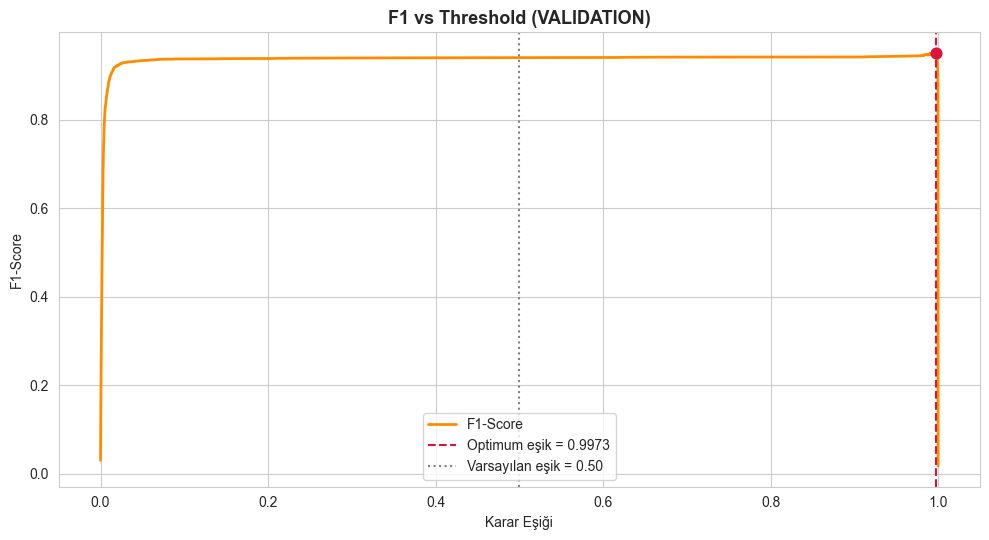

In [16]:
best_params = study.best_params.copy()
best_params.update({
    "scale_pos_weight": scale_pos_weight, "subsample_freq": 1,
    "boost_from_average": False, "random_state": RANDOM_STATE,
    "n_jobs": -1, "verbose": -1,
})

final_op_model = lgb.LGBMClassifier(**best_params)
final_op_model.fit(Xs_train, y_train)

val_proba = final_op_model.predict_proba(Xs_val)[:, 1]
prec_v, rec_v, thr_v = precision_recall_curve(y_val, val_proba)
f1s_v = np.divide(2*prec_v*rec_v, prec_v+rec_v,
                   out=np.zeros_like(prec_v), where=(prec_v+rec_v) != 0)
best_threshold = thr_v[np.argmax(f1s_v[:-1])]

print(f"Validasyonda F1'i maksimize eden eşik: {best_threshold:.4f}")
print(f"Bu eşikteki validation F1: {f1s_v[np.argmax(f1s_v[:-1])]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(thr_v, f1s_v[:-1], color="darkorange", lw=2, label="F1-Score")
ax.axvline(best_threshold, color="crimson", ls="--", label=f"Optimum eşik = {best_threshold:.4f}")
ax.axvline(0.50, color="gray", ls=":", label="Varsayılan eşik = 0.50")
ax.scatter([best_threshold], [f1s_v[np.argmax(f1s_v[:-1])]], color="crimson", zorder=5, s=60)
ax.set_xlabel("Karar Eşiği"); ax.set_ylabel("F1-Score")
ax.set_title("F1 vs Threshold (VALIDATION)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### Threshold Sonucunun Yorumu

Validation setinde F1-Score'u en yüksek yapan eşik **0,9973** olarak bulunmuştur.

Ancak test döneminde:

- LightGBM F1 @ 0,50 = **0,9698**
- LightGBM F1 @ 0,9973 = **0,9538**

elde edilmiştir.

Validation'da optimum olan bir eşik değerinin test döneminde mutlaka daha yüksek F1 sağlaması beklenmez. Bunun temel nedeni train, validation ve test dönemlerindeki fraud oranlarının birbirinden oldukça farklı olmasıdır.

Bu sonuç bir modelleme hatası değil, **distribution shift** etkisinin önemli bir örneğidir. Ayrıca threshold seçiminin işletme amacına göre yapılması gerektiğini göstermektedir. Örneğin fraud kaçırmanın maliyeti yüksekse Recall daha fazla önemsenebilir; çok fazla yanlış alarm operasyon yükü oluşturuyorsa Precision daha kritik hale gelebilir.

Bu nedenle H4, “eşik optimizasyonu performansı her zaman artırır” şeklinde değil, **eşik seçiminin Precision–Recall dengesini ve sınıflandırma davranışını değiştirdiği** şeklinde yorumlanmıştır.

## 9. Final Değerlendirme — Test Seti

Test seti model geliştirme sürecinde tamamen dışarıda tutulmuştur.

Test verileri:

- model eğitiminde,
- Optuna hiperparametre optimizasyonunda,
- karar eşiğinin belirlenmesinde

kullanılmamıştır.

Test seti yalnızca geliştirme süreci tamamlandıktan sonra modellerin daha önce görmedikleri son zaman dilimindeki performanslarını ölçmek amacıyla kullanılmıştır. Bu yaklaşım model performansının daha tarafsız ve gerçekçi değerlendirilmesini sağlar.

                            TEST SONUCLARI                            
Metrik                        RF (esik=0.50)      LGBM (val esigi)
----------------------------------------------------------------------
PR-AUC                                0.9995                0.9948
ROC-AUC                               1.0000                0.9998
Precision (Fraud)                     0.9976                0.9679
Recall (Fraud)                        0.9984                0.9401
F1 (Fraud)                            0.9980                0.9538

LightGBM threshold (val'den): 0.9973
LightGBM F1 @ 0.50: 0.9698
LightGBM F1 @ Val esigi: 0.9538
Not: PR-AUC ve ROC-AUC esikten bagimsizdir ve modeller arasi ana karsilastirma icin kullanilir.
Precision/Recall/F1 satirlari farkli esik politikalarini gosterdigi icin dogrudan adil model siralamasi olarak yorumlanmamalidir.


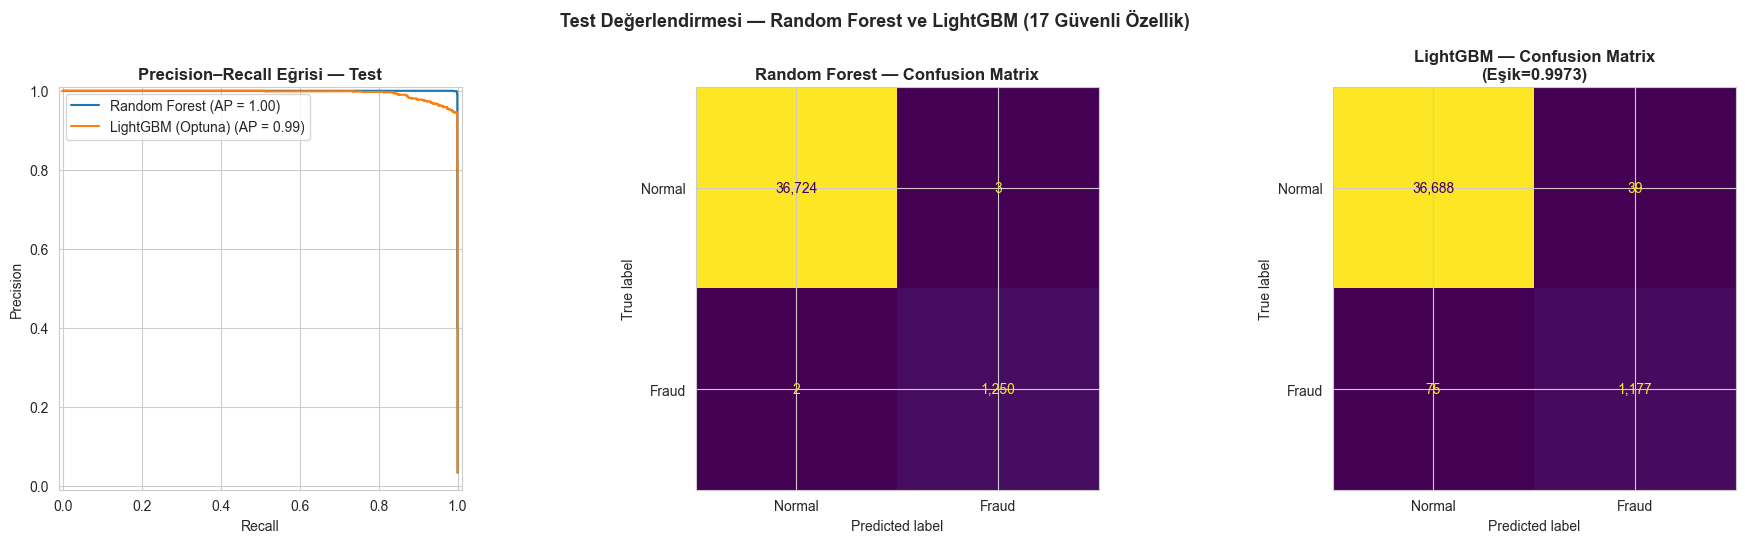

In [17]:
# ─── LightGBM (Optuna) — Test degerlendirmesi ────────────────────────────
lgb_test_proba = final_op_model.predict_proba(Xs_test)[:, 1]
lgb_test_pred_default = (lgb_test_proba >= 0.50).astype(int)
lgb_test_pred_optimal = (lgb_test_proba >= best_threshold).astype(int)

lgb_test_pr_auc = average_precision_score(y_test, lgb_test_proba)
lgb_test_roc_auc = roc_auc_score(y_test, lgb_test_proba)

# ─── Random Forest — Test degerlendirmesi ─────────────────────────────
rf_test_proba = rf_model.predict_proba(Xs_test)[:, 1]
rf_test_pred = (rf_test_proba >= 0.50).astype(int)
rf_test_pr_auc = average_precision_score(y_test, rf_test_proba)
rf_test_roc_auc = roc_auc_score(y_test, rf_test_proba)

# ─── Karsilastirma tablosu ────────────────────────────────────────────
# Eski degisken adlarini koruyalim (sonraki hucreler bunlari kullaniyor)
test_proba = lgb_test_proba
test_pred_default = lgb_test_pred_default
test_pred_optimal = lgb_test_pred_optimal
test_pr_auc = lgb_test_pr_auc
test_roc_auc = lgb_test_roc_auc

print("=" * 70)
print(f"{'TEST SONUCLARI':^70s}")
print("=" * 70)
print(f"{'Metrik':22s}{'RF (esik=0.50)':>22s}{'LGBM (val esigi)':>22s}")
print("-" * 70)
print(f"{'PR-AUC':22s}{rf_test_pr_auc:>22.4f}{lgb_test_pr_auc:>22.4f}")
print(f"{'ROC-AUC':22s}{rf_test_roc_auc:>22.4f}{lgb_test_roc_auc:>22.4f}")
print(f"{'Precision (Fraud)':22s}{precision_score(y_test, rf_test_pred):>22.4f}{precision_score(y_test, lgb_test_pred_optimal):>22.4f}")
print(f"{'Recall (Fraud)':22s}{recall_score(y_test, rf_test_pred):>22.4f}{recall_score(y_test, lgb_test_pred_optimal):>22.4f}")
print(f"{'F1 (Fraud)':22s}{f1_score(y_test, rf_test_pred):>22.4f}{f1_score(y_test, lgb_test_pred_optimal):>22.4f}")
print("=" * 70)

print(f"\nLightGBM threshold (val'den): {best_threshold:.4f}")
print(f"LightGBM F1 @ 0.50: {f1_score(y_test, lgb_test_pred_default):.4f}")
print(f"LightGBM F1 @ Val esigi: {f1_score(y_test, lgb_test_pred_optimal):.4f}")
print("Not: PR-AUC ve ROC-AUC esikten bagimsizdir ve modeller arasi ana karsilastirma icin kullanilir.")
print("Precision/Recall/F1 satirlari farkli esik politikalarini gosterdigi icin dogrudan adil model siralamasi olarak yorumlanmamalidir.")

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

# Precision–Recall eğrileri
ax = axes[0]
prec_t, rec_t, _ = precision_recall_curve(y_test, lgb_test_proba)
rf_prec_t, rf_rec_t, _ = precision_recall_curve(y_test, rf_test_proba)

PrecisionRecallDisplay(
    precision=rf_prec_t,
    recall=rf_rec_t,
    average_precision=rf_test_pr_auc
).plot(ax=ax, name="Random Forest")

PrecisionRecallDisplay(
    precision=prec_t,
    recall=rec_t,
    average_precision=lgb_test_pr_auc
).plot(ax=ax, name="LightGBM (Optuna)")

ax.set_title("Precision–Recall Eğrisi — Test", fontsize=12, fontweight="bold")
ax.legend()

# Random Forest Confusion Matrix
ax = axes[1]
cm_rf = confusion_matrix(y_test, rf_test_pred)
ConfusionMatrixDisplay(
    cm_rf,
    display_labels=["Normal", "Fraud"]
).plot(ax=ax, colorbar=False, values_format=",")
ax.set_title("Random Forest — Confusion Matrix", fontsize=12, fontweight="bold")

# LightGBM Confusion Matrix
ax = axes[2]
cm_lgb = confusion_matrix(y_test, lgb_test_pred_optimal)
ConfusionMatrixDisplay(
    cm_lgb,
    display_labels=["Normal", "Fraud"]
).plot(ax=ax, colorbar=False, values_format=",")
ax.set_title(
    f"LightGBM — Confusion Matrix\n(Eşik={best_threshold:.4f})",
    fontsize=12,
    fontweight="bold"
)

plt.suptitle(
    "Test Değerlendirmesi — Random Forest ve LightGBM (17 Güvenli Özellik)",
    fontsize=13,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


### Test Sonuçlarının Yorumu

Test setinde elde edilen temel sonuçlar:

| Metrik | Random Forest | LightGBM |
|---|---:|---:|
| PR-AUC | **0,9995** | 0,9948 |
| ROC-AUC | **1,0000** | 0,9998 |
| Precision (Fraud) | **0,9976** | 0,9679 |
| Recall (Fraud) | **0,9984** | 0,9401 |
| F1-Score (Fraud) | **0,9980** | 0,9538 |

Model sıralamasında özellikle **PR-AUC** dikkate alınmıştır. Bunun nedeni fraud sınıfının çok nadir olmasıdır. PR-AUC, modelin fraud sınıfındaki Precision–Recall dengesini bütün olası eşikler boyunca değerlendirdiği için dengesiz veri problemlerinde oldukça anlamlıdır.

Random Forest'ın test PR-AUC değeri **0,9995** ile LightGBM'in **0,9948** değerinden daha yüksektir. Bu nedenle bu veri setindeki **performans lideri Random Forest** olarak değerlendirilmiştir.

LightGBM ise büyük veri setlerinde daha hızlı eğitim ve tahmin avantajı, Optuna ile kolay optimize edilebilmesi ve ölçeklenebilirliği nedeniyle güçlü bir operasyonel alternatif olarak ele alınmıştır.

Precision, Recall ve F1 değerlerinde modeller farklı threshold politikalarıyla gösterildiği için bu satırlar doğrudan tamamen adil bir model sıralaması olarak yorumlanmamalıdır. Modeller arasında threshold'dan bağımsız ana karşılaştırma PR-AUC ve ROC-AUC üzerinden yapılmıştır.

### Çok Yüksek Skorların Yorumu

Random Forest'ın neredeyse kusursuz sonuç vermesi özellikle dikkat edilmesi gereken bir noktadır. PaySim gerçek banka verisi değil, gerçek işlem davranışlarını taklit etmek amacıyla oluşturulmuş **sentetik bir veri setidir**. Fraud örüntüleri gerçek dünyaya kıyasla daha düzenli olabilir ve ağaç tabanlı modeller bu örüntüleri çok güçlü biçimde öğrenebilir.

Bu nedenle elde edilen yüksek skorların gerçek bir banka veya ödeme kuruluşunda aynı seviyede gerçekleşeceği varsayılmamalıdır.

## 10. Veri Sızıntısı Deneyi — Operasyonel ve Tam Özellik Modeli

Bu bölümde ana operasyonel modelde bilinçli olarak kullanılmayan işlem sonrası bakiye değişkenlerinin modele eklenmesi durumunda performansın nasıl değiştiği incelenmiştir.

### Operasyonel Model

Yalnızca işlem sırasında veya işlemden önce bilinebilecek **17 güvenli özellik** kullanılmıştır.

### Tam Özellik Modeli

Operasyonel özelliklere ek olarak:

- `newbalanceOrig`
- `newbalanceDest`
- `errorBalanceOrig`
- `errorBalanceDest`

değişkenleri dahil edilmiş ve toplam **21 özellik** kullanılmıştır.

Bu dört değişken işlemin sonucuna ait bilgi içerdiğinden gerçek zamanlı tahmin açısından modelin gelecekte bilmemesi gereken bilgileri modele taşıyabilir. Bu durum **data leakage (veri sızıntısı)** olarak değerlendirilmiştir.

                            SIZINTI DENEYİ                            
Metrik                    Operasyonel (17 öz.)    Tam Özellik (21 öz.)
----------------------------------------------------------------------
PR-AUC                                  0.9948                  1.0000
ROC-AUC                                 0.9998                  1.0000
Precision (Fraud)                       0.9679                  1.0000
Recall (Fraud)                          0.9401                  0.9992
F1 (Fraud)                              0.9538                  0.9996


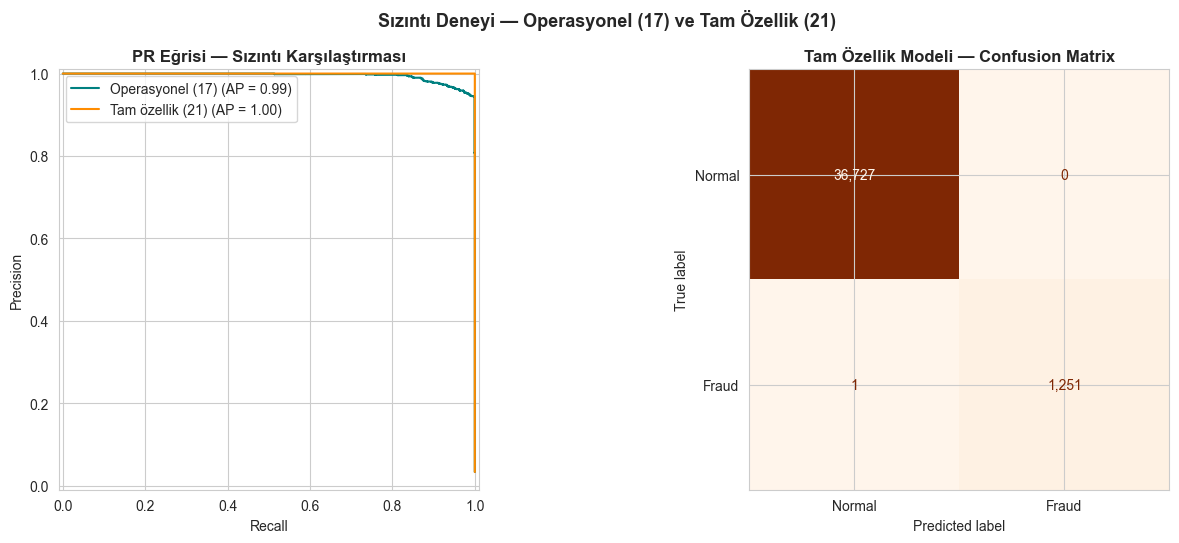

In [18]:
# Tam özellik modeli — temel parametrelerle (Optuna yok, bu bir deney)
leakage_model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=8, num_leaves=31,
    subsample=0.8, subsample_freq=1,
    scale_pos_weight=scale_pos_weight, boost_from_average=False,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
leakage_model.fit(X_train, y_train)   # ALL_FEATURES ile

leak_test_proba = leakage_model.predict_proba(X_test)[:, 1]
leak_test_pred = (leak_test_proba >= 0.50).astype(int)
leak_pr_auc = average_precision_score(y_test, leak_test_proba)
leak_roc_auc = roc_auc_score(y_test, leak_test_proba)

print("=" * 70)
print(f"{'SIZINTI DENEYİ':^70s}")
print("=" * 70)
print(f"{'Metrik':22s}{'Operasyonel (17 öz.)':>24s}{'Tam Özellik (21 öz.)':>24s}")
print("-" * 70)
print(f"{'PR-AUC':22s}{test_pr_auc:>24.4f}{leak_pr_auc:>24.4f}")
print(f"{'ROC-AUC':22s}{test_roc_auc:>24.4f}{leak_roc_auc:>24.4f}")
print(f"{'Precision (Fraud)':22s}{precision_score(y_test, test_pred_optimal):>24.4f}{precision_score(y_test, leak_test_pred):>24.4f}")
print(f"{'Recall (Fraud)':22s}{recall_score(y_test, test_pred_optimal):>24.4f}{recall_score(y_test, leak_test_pred):>24.4f}")
print(f"{'F1 (Fraud)':22s}{f1_score(y_test, test_pred_optimal):>24.4f}{f1_score(y_test, leak_test_pred):>24.4f}")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ax = axes[0]
leak_prec_t, leak_rec_t, _ = precision_recall_curve(y_test, leak_test_proba)
PrecisionRecallDisplay(precision=prec_t, recall=rec_t,
                        average_precision=test_pr_auc).plot(ax=ax, color="teal", name="Operasyonel (17)")
PrecisionRecallDisplay(precision=leak_prec_t, recall=leak_rec_t,
                        average_precision=leak_pr_auc).plot(ax=ax, color="darkorange", name="Tam özellik (21)")
ax.set_title("PR Eğrisi — Sızıntı Karşılaştırması", fontsize=12, fontweight="bold")
ax.legend()

ax = axes[1]
cm_leak = confusion_matrix(y_test, leak_test_pred)
ConfusionMatrixDisplay(cm_leak, display_labels=["Normal", "Fraud"]).plot(
    ax=ax, cmap="Oranges", colorbar=False, values_format=",")
ax.set_title("Tam Özellik Modeli — Confusion Matrix", fontsize=12, fontweight="bold")

plt.suptitle("Sızıntı Deneyi — Operasyonel (17) ve Tam Özellik (21)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Sızıntı Deneyi Sonucu

Tam özellik modelinde:

- **PR-AUC = 1,0000**
- **ROC-AUC = 1,0000**
- **F1-Score = 0,9996**

elde edilmiştir.

Operasyonel LightGBM modelinin PR-AUC değeri ise **0,9948**'dir.

Tam özellik modelinin neredeyse kusursuz sonuca ulaşması, işlem sonrası bakiye bilgilerinin fraud hedefi hakkında çok güçlü bilgi taşıdığını göstermektedir.

Bu sonuç **H5 hipotezini doğrulamaktadır.**

Aynı zamanda **H2 hipotezi koşullu olarak doğrulanmıştır:** bakiye tutarsızlıklarını temsil eden `errorBalanceOrig` ve `errorBalanceDest` güçlü fraud sinyali taşımaktadır; ancak bu değişkenler işlem sonrası bilgi kullandığı için gerçek zamanlı operasyonel modelde kullanılması uygun değildir.

Bu deneyin amacı daha yüksek skorlu modeli final model olarak seçmek değil, **veri sızıntısının model performansını nasıl yapay biçimde yükseltebildiğini göstermek**tir.

## 11. SHAP ile Model Açıklanabilirliği

Yüksek performanslı bir fraud modelinin yalnızca doğru tahmin yapması değil, kararlarını hangi değişkenlere dayandırdığının da anlaşılabilmesi önemlidir.

Bu nedenle çalışmada **SHAP (SHapley Additive exPlanations)** yöntemi kullanılmıştır.

SHAP, her özelliğin model tahmini üzerindeki katkısını hesaplayarak:

- hangi değişkenlerin en önemli olduğunu,
- değişkenlerin fraud tahminlerini hangi yönde etkilediğini,
- operasyonel model ile sızıntılı model arasındaki farkı

incelemeye yardımcı olur.

SHAP analizi iki ayrı model üzerinde uygulanmıştır:

1. **Operasyonel LightGBM modeli — 17 güvenli özellik**
2. **Tam özellik LightGBM modeli — 21 özellik**

Bu karşılaştırmanın amacı, gerçek zamanlı olarak kullanılabilecek modelin hangi sinyallere dayandığını ve işlem sonrası bakiye değişkenlerinin tam özellik modelindeki etkisini açık biçimde göstermektir.

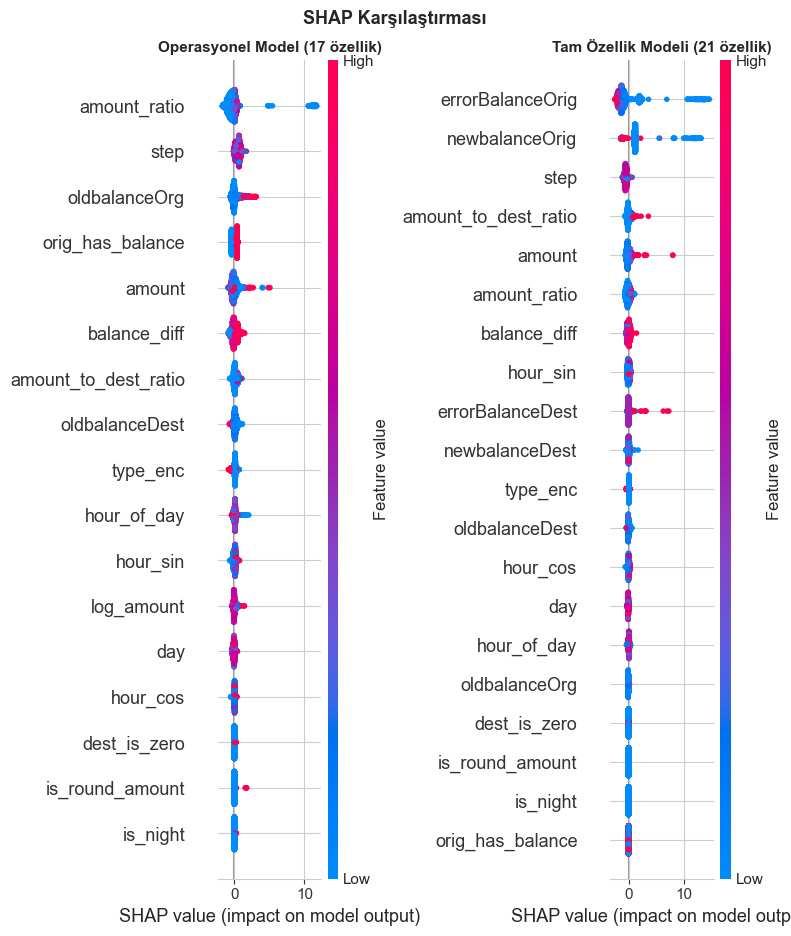

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Operasyonel model SHAP
Xs_sample = Xs_test.sample(min(2000, len(Xs_test)), random_state=RANDOM_STATE)
exp_op = shap.TreeExplainer(final_op_model)
sv_op = exp_op.shap_values(Xs_sample)
sv_op_fraud = sv_op[1] if isinstance(sv_op, list) else sv_op

plt.sca(axes[0])
shap.summary_plot(sv_op_fraud, Xs_sample, show=False)
axes[0].set_title("Operasyonel Model (17 özellik)", fontsize=11, fontweight="bold")

# Tam özellik model SHAP
X_sample = X_test.sample(min(2000, len(X_test)), random_state=RANDOM_STATE)
exp_full = shap.TreeExplainer(leakage_model)
sv_full = exp_full.shap_values(X_sample)
sv_full_fraud = sv_full[1] if isinstance(sv_full, list) else sv_full

plt.sca(axes[1])
shap.summary_plot(sv_full_fraud, X_sample, show=False)
axes[1].set_title("Tam Özellik Modeli (21 özellik)", fontsize=11, fontweight="bold")

plt.suptitle("SHAP Karşılaştırması", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
# Onem siralamasi — operasyonel model
mean_shap_op = np.abs(sv_op_fraud).mean(axis=0)
imp_op = pd.DataFrame({"Ozellik": Xs_sample.columns, "SHAP": mean_shap_op}
                       ).sort_values("SHAP", ascending=False).reset_index(drop=True)
print("Operasyonel Model — Özellik Önemi:")
print(imp_op.round(4))

# Onem siralamasi — tam ozellik
mean_shap_full = np.abs(sv_full_fraud).mean(axis=0)
imp_full = pd.DataFrame({"Ozellik": X_sample.columns, "SHAP": mean_shap_full}
                         ).sort_values("SHAP", ascending=False).reset_index(drop=True)
print("\nTam Özellik Modeli — Özellik Önemi:")
print(imp_full.round(4))

Operasyonel Model — Özellik Önemi:
                 Ozellik    SHAP
0           amount_ratio  0.8730
1                   step  0.4986
2          oldbalanceOrg  0.3850
3       orig_has_balance  0.3421
4                 amount  0.3132
5           balance_diff  0.2958
6   amount_to_dest_ratio  0.2082
7         oldbalanceDest  0.1867
8               type_enc  0.1637
9            hour_of_day  0.1386
10              hour_sin  0.1283
11            log_amount  0.1201
12                   day  0.1050
13              hour_cos  0.0600
14          dest_is_zero  0.0164
15       is_round_amount  0.0056
16              is_night  0.0033

Tam Özellik Modeli — Özellik Önemi:
                 Ozellik    SHAP
0       errorBalanceOrig  1.7582
1         newbalanceOrig  1.5038
2                   step  0.5120
3   amount_to_dest_ratio  0.2844
4                 amount  0.2715
5           amount_ratio  0.2655
6           balance_diff  0.2059
7               hour_sin  0.1418
8       errorBalanceDest  0.1269
9   

### SHAP Sonuçlarının Yorumu

Operasyonel LightGBM modelinde en önemli üç değişken:

1. **`amount_ratio` — |SHAP| = 0,8730**
2. **`step` — |SHAP| = 0,4986**
3. **`oldbalanceOrg` — |SHAP| = 0,3850**

olarak bulunmuştur.

`amount_ratio`, işlem tutarının göndericinin mevcut bakiyesine göre ne kadar büyük olduğunu temsil etmektedir. Bu değişkenin en yüksek SHAP önemine sahip olması, fraud tespitinde yalnızca işlem tutarının değil, tutarın hesap bakiyesiyle ilişkisinin de önemli olduğunu göstermektedir.

`step` değişkeninin yüksek önem göstermesi fraud davranışının zaman içerisinde aynı oranda dağılmadığını desteklemektedir.

`oldbalanceOrg` ise göndericinin işlem öncesi mali durumunun model açısından güçlü bir sinyal olduğunu göstermektedir.

Tam özellik modelinde ise en etkili iki değişken:

- `errorBalanceOrig`
- `newbalanceOrig`

olmuştur.

Bu sonuç, işlem sonrası bakiye bilgilerinin modele çok güçlü bir avantaj sağladığını ve sızıntı deneyindeki performans artışının kaynağını SHAP analizi ile de desteklemektedir.

## 12. Sonuç ve Hipotezlerin Değerlendirilmesi

Bu proje kapsamında PaySim mobil para transferi verisi üzerinde fraud tespiti için uçtan uca bir makine öğrenmesi süreci uygulanmıştır.

Çalışmada veri keşfi, feature engineering, sınıf dengesizliği yönetimi, zamansal veri ayrımı, farklı algoritmaların karşılaştırılması, hiperparametre optimizasyonu, threshold optimizasyonu, veri sızıntısı analizi ve SHAP açıklanabilirliği birlikte ele alınmıştır.

In [21]:
print("=" * 65)
print("  FİNAL ÖZET")
print("=" * 65)
print(f"  Zamansal split : Train {len(y_train):,} / Val {len(y_val):,} / Test {len(y_test):,}")
print(f"  RF (test)      - PR-AUC: {rf_test_pr_auc:.4f}  ROC-AUC: {rf_test_roc_auc:.4f}")
print(f"  LightGBM (test)- PR-AUC: {lgb_test_pr_auc:.4f}  ROC-AUC: {lgb_test_roc_auc:.4f}")
print(f"  Tam özellik    - PR-AUC: {leak_pr_auc:.4f}  ROC-AUC: {leak_roc_auc:.4f}")
print(f"  Threshold (validation setinden seçildi) : {best_threshold:.4f}")
print("-" * 65)
print("  SHAP - En Etkili Özellikler (operasyonel model):")
for i, row in imp_op.head(3).iterrows():
    print(f"    {i+1}. {row['Ozellik']}  (|SHAP| = {row['SHAP']:.4f})")
print("=" * 65)

  FİNAL ÖZET
  Zamansal split : Train 2,653,729 / Val 78,701 / Test 37,979
  RF (test)      - PR-AUC: 0.9995  ROC-AUC: 1.0000
  LightGBM (test)- PR-AUC: 0.9948  ROC-AUC: 0.9998
  Tam özellik    - PR-AUC: 1.0000  ROC-AUC: 1.0000
  Threshold (validation setinden seçildi) : 0.9973
-----------------------------------------------------------------
  SHAP - En Etkili Özellikler (operasyonel model):
    1. amount_ratio  (|SHAP| = 0.8730)
    2. step  (|SHAP| = 0.4986)
    3. oldbalanceOrg  (|SHAP| = 0.3850)


### Araştırma Hipotezlerinin Sonuçları

| # | Hipotez | Sonuç | Kanıt |
|---|---|---|---|
| **H1** | Fraud belirli işlem türlerinde yoğunlaşmaktadır. | **Doğrulandı** | Fraud yalnızca TRANSFER ve CASH_OUT işlemlerinde görülmüştür. |
| **H2** | Bakiye tutarsızlığı değişkenleri fraud sinyalini güçlendirir. | **Koşullu olarak doğrulandı** | İşlem sonrası bakiye değişkenleri güçlü sinyal taşımıştır; ancak gerçek zamanlı kullanımda veri sızıntısı oluştururlar. |
| **H3** | Gözetimli modeller gözetimsiz modelden daha başarılıdır. | **Doğrulandı** | RF ve LightGBM, Isolation Forest'tan belirgin şekilde daha yüksek PR-AUC elde etmiştir. |
| **H4** | Threshold optimizasyonu sınıflandırma davranışını değiştirir. | **Doğrulandı** | Validation'da seçilen 0,9973 eşiği Precision–Recall/F1 dengesini değiştirmiştir. |
| **H5** | İşlem sonrası değişkenlerin kullanılması performansı yapay biçimde yükseltir. | **Doğrulandı** | Tam özellik modelinde PR-AUC 1,0000'a yükselmiştir. |
| **H6** | Fraud oranı zaman içerisinde değişmektedir. | **Doğrulandı** | Fraud oranı Train'de %0,2178 iken Test'te %3,2966'ya yükselmiştir; yaklaşık 15 kat fark vardır. |

---

## Final Model Değerlendirmesi

Bu veri setinde en yüksek test PR-AUC değerini **Random Forest (0,9995)** elde etmiştir. Bu nedenle saf model performansı açısından final tercih adayı Random Forest'tır.

LightGBM'in test PR-AUC değeri **0,9948** ile yine oldukça güçlüdür. LightGBM; milyonlarca satırlık veri üzerinde hızlı çalışması, kolay ölçeklenebilmesi ve Optuna gibi optimizasyon araçlarıyla birlikte kullanılabilmesi nedeniyle operasyonel açıdan güçlü bir alternatif olarak değerlendirilmiştir.

Isolation Forest'ın düşük performansı, bu veri setinde yalnızca anomalilik yaklaşımının fraud sınıfını ayırmak için yeterli olmadığını göstermiştir.

---

## Kullanılan Değerlendirme Metrikleri

### Precision

Modelin fraud olarak işaretlediği işlemlerin ne kadarının gerçekten fraud olduğunu gösterir.

**Yüksek Precision → Daha az yanlış fraud alarmı.**

### Recall

Gerçek fraud işlemlerinin ne kadarının model tarafından yakalandığını gösterir.

**Yüksek Recall → Daha az fraud işlemi kaçırılır.**

Finansal dolandırıcılık problemlerinde fraud kaçırmanın maliyeti yüksek olabileceği için Recall özellikle önemlidir.

### F1-Score

Precision ve Recall'un harmonik ortalamasıdır. İki metriğin birlikte dengeli şekilde değerlendirilmesini sağlar.

### ROC-AUC

Modelin normal ve fraud sınıflarını genel olarak ayırabilme gücünü ölçer.

### PR-AUC

Precision–Recall eğrisinin altında kalan alandır. Fraud gibi **pozitif sınıfın çok nadir olduğu dengesiz veri setlerinde** ROC-AUC'ye göre daha bilgilendirici olabilir. Bu nedenle bu projede ana karşılaştırma metriği olarak özellikle PR-AUC dikkate alınmıştır.

---

## Projenin Kısıtları

1. **PaySim sentetik bir veri setidir.** Sonuçların gerçek banka veya ödeme kuruluşu verisine birebir genellenmesi doğru değildir.
2. Modelleme yalnızca fraud görülen **TRANSFER ve CASH_OUT** işlem türlerinde gerçekleştirilmiştir.
3. `nameOrig` ve `nameDest` gibi hesap kimliklerinden ağ veya müşteri geçmişi özellikleri oluşturulmamıştır.
4. Gerçek hayatta müşteri profili, cihaz bilgisi, IP, coğrafi konum, işlem geçmişi ve merchant bilgisi gibi ek değişkenler fraud tespitini önemli ölçüde etkileyebilir.
5. Train, validation ve test dönemlerinde fraud oranlarının değişmesi **distribution shift** bulunduğunu göstermektedir.
6. Validation'da optimum bulunan bir threshold'un gelecekteki her dönemde aynı sonucu vermesi beklenmemelidir. Gerçek sistemde threshold düzenli olarak izlenmeli ve işletme maliyetlerine göre yeniden değerlendirilmelidir.

---

## Genel Sonuç

Çalışmanın en önemli sonucu, yüksek performanslı bir fraud modelinin yalnızca yüksek skor elde etmekten ibaret olmadığıdır. Gerçekçi bir model geliştirmek için:

- zaman sırasının korunması,
- veri sızıntısının önlenmesi,
- sınıf dengesizliğinin dikkate alınması,
- doğru değerlendirme metriklerinin seçilmesi,
- model kararlarının açıklanabilmesi

gerekmektedir.

Bu proje, PaySim veri seti üzerinde bu adımların tamamını bir arada uygulayan uçtan uca bir dolandırıcılık tespiti çalışmasıdır.